# EDA inicial (data cruda)

## Exploración Inicial

In [5]:
import pandas as pd
import numpy as np
# Cargar datos 
data =  pd.read_csv(r"C:\Users\sdiaz\Documents\upc\7\machin learning\PC$\data\criptodataset.csv")

In [6]:
eda_data = data.copy()

In [55]:
eda_data.head()

,date,price,market_cap,volume,token,name,tvl_usd,volume_to_marketcap,price_change_%,market_cap_trend,tvl_trend,narrative
0,2024-06-01,0.021743,2.677851e+08,4.748500e+06,one,Harmony,2870121,0.017732,NaN,NaN,NaN,Desconocido
1,2024-06-02,0.021809,2.682872e+08,3.105342e+06,one,Harmony,2927085,0.011575,0.303395,0.187511,1.984725,Desconocido
2,2024-06-03,0.021625,2.661746e+08,6.740671e+06,one,Harmony,2832820,0.025324,-0.843260,-0.787463,-3.220439,Desconocido
3,2024-06-04,0.022032,2.707636e+08,6.316662e+06,one,Harmony,2929770,0.023329,1.885679,1.724051,3.422385,Desconocido
4,2024-06-05,0.022940,2.822307e+08,6.750956e+06,one,Harmony,2433359,0.023920,4.121088,4.235119,-16.943685,Desconocido


In [56]:
eda_data.describe()

,price,market_cap,volume,tvl_usd,volume_to_marketcap,price_change_%,market_cap_trend,tvl_trend
count,1740.000000,1.740000e+03,1.740000e+03,1.740000e+03,1740.000000,1735.000000,1735.000000,1735.000000
mean,0.224612,1.777126e+08,1.127639e+07,3.309387e+07,0.048381,-0.161313,-0.103440,0.339615
std,0.295149,1.808609e+08,2.096859e+07,6.502968e+07,0.057917,5.096132,5.098647,11.335973
min,0.000983,2.635667e+06,1.011485e+03,7.246400e+04,0.000199,-20.419520,-20.265189,-68.589293
25%,0.010654,9.298688e+06,1.233864e+05,3.205822e+05,0.010254,-2.721573,-2.741799,-2.811987
50%,0.016684,1.505689e+08,6.025160e+06,1.133220e+06,0.035491,-0.253257,-0.156880,0.000000
75%,0.453352,2.947722e+08,1.344001e+07,2.455542e+06,0.063734,2.098528,2.180865,2.352405
max,1.853151,7.748413e+08,3.250321e+08,2.217892e+08,0.843553,44.344404,44.223039,223.317782


In [57]:
eda_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 1740 non-null   object 
 1   price                1740 non-null   float64
 2   market_cap           1740 non-null   float64
 3   volume               1740 non-null   float64
 4   token                1740 non-null   object 
 5   name                 1740 non-null   object 
 6   tvl_usd              1740 non-null   int64  
 7   volume_to_marketcap  1740 non-null   float64
 8   price_change_%       1735 non-null   float64
 9   market_cap_trend     1735 non-null   float64
 10  tvl_trend            1735 non-null   float64
 11  narrative            1740 non-null   object 
dtypes: float64(7), int64(1), object(4)
memory usage: 163.2+ KB


## Verificacion de valores nulos y duplicados

In [58]:

print(eda_data.isnull().sum())

date                   0
price                  0
market_cap             0
volume                 0
token                  0
name                   0
tvl_usd                0
volume_to_marketcap    0
price_change_%         5
market_cap_trend       5
tvl_trend              5
narrative              0
dtype: int64


In [7]:
'''
Los nulos de son los primeros registros de cada token por lo que los vamos a dropear 
'''

# Eliminar esas 5 filas nulas (no afecta la calidad del dataset)
# eda_data = eda_data.dropna(subset=["price_change_%", "market_cap_trend", "tvl_trend"])
eda_data = eda_data.fillna(0)


In [60]:
print(eda_data.isnull().sum())

date                   0
price                  0
market_cap             0
volume                 0
token                  0
name                   0
tvl_usd                0
volume_to_marketcap    0
price_change_%         0
market_cap_trend       0
tvl_trend              0
narrative              0
dtype: int64


In [61]:
print(eda_data.duplicated().sum())

0


In [8]:
'''
Borramos la columna narrative ya que no aporta nada al modelo
todos los valores son "desconocido"
'''

eda_data.drop(columns=["narrative"],inplace=True)

In [63]:
eda_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 1740 non-null   object 
 1   price                1740 non-null   float64
 2   market_cap           1740 non-null   float64
 3   volume               1740 non-null   float64
 4   token                1740 non-null   object 
 5   name                 1740 non-null   object 
 6   tvl_usd              1740 non-null   int64  
 7   volume_to_marketcap  1740 non-null   float64
 8   price_change_%       1740 non-null   float64
 9   market_cap_trend     1740 non-null   float64
 10  tvl_trend            1740 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 149.7+ KB


## Distribucíon de variables numéricas por cada token

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
numeric_columns = eda_data.select_dtypes(include='number').columns

In [11]:
from scipy.stats import skew, kurtosis, shapiro

In [67]:
def plot_numeric_distributions(data, numeric_cols):  
    cols_per_row = 2
    n = len(numeric_cols)
    rows = -(-n // cols_per_row)  

    plt.figure(figsize=(cols_per_row * 7, rows * 4))

    for idx, col in enumerate(numeric_cols, 1):
        sk = skew(data[col].dropna())
        kt = kurtosis(data[col].dropna())
        _, p = shapiro(data[col].dropna())

        plt.subplot(rows, cols_per_row*2, idx*2-1)
        sns.histplot(data[col], kde=True, bins=20, color="skyblue")
        plt.title(f"{col}\nSkew: {sk:.2f}, Kurt: {kt:.2f}, p={p:.2g}")

        plt.subplot(rows, cols_per_row*2, idx*2)
        sns.boxplot(x=data[col], color="lightcoral")
        plt.title(f"{col} - Boxplot")

    plt.tight_layout()
    plt.show()

### Distribución de variables numéricas para Harmony


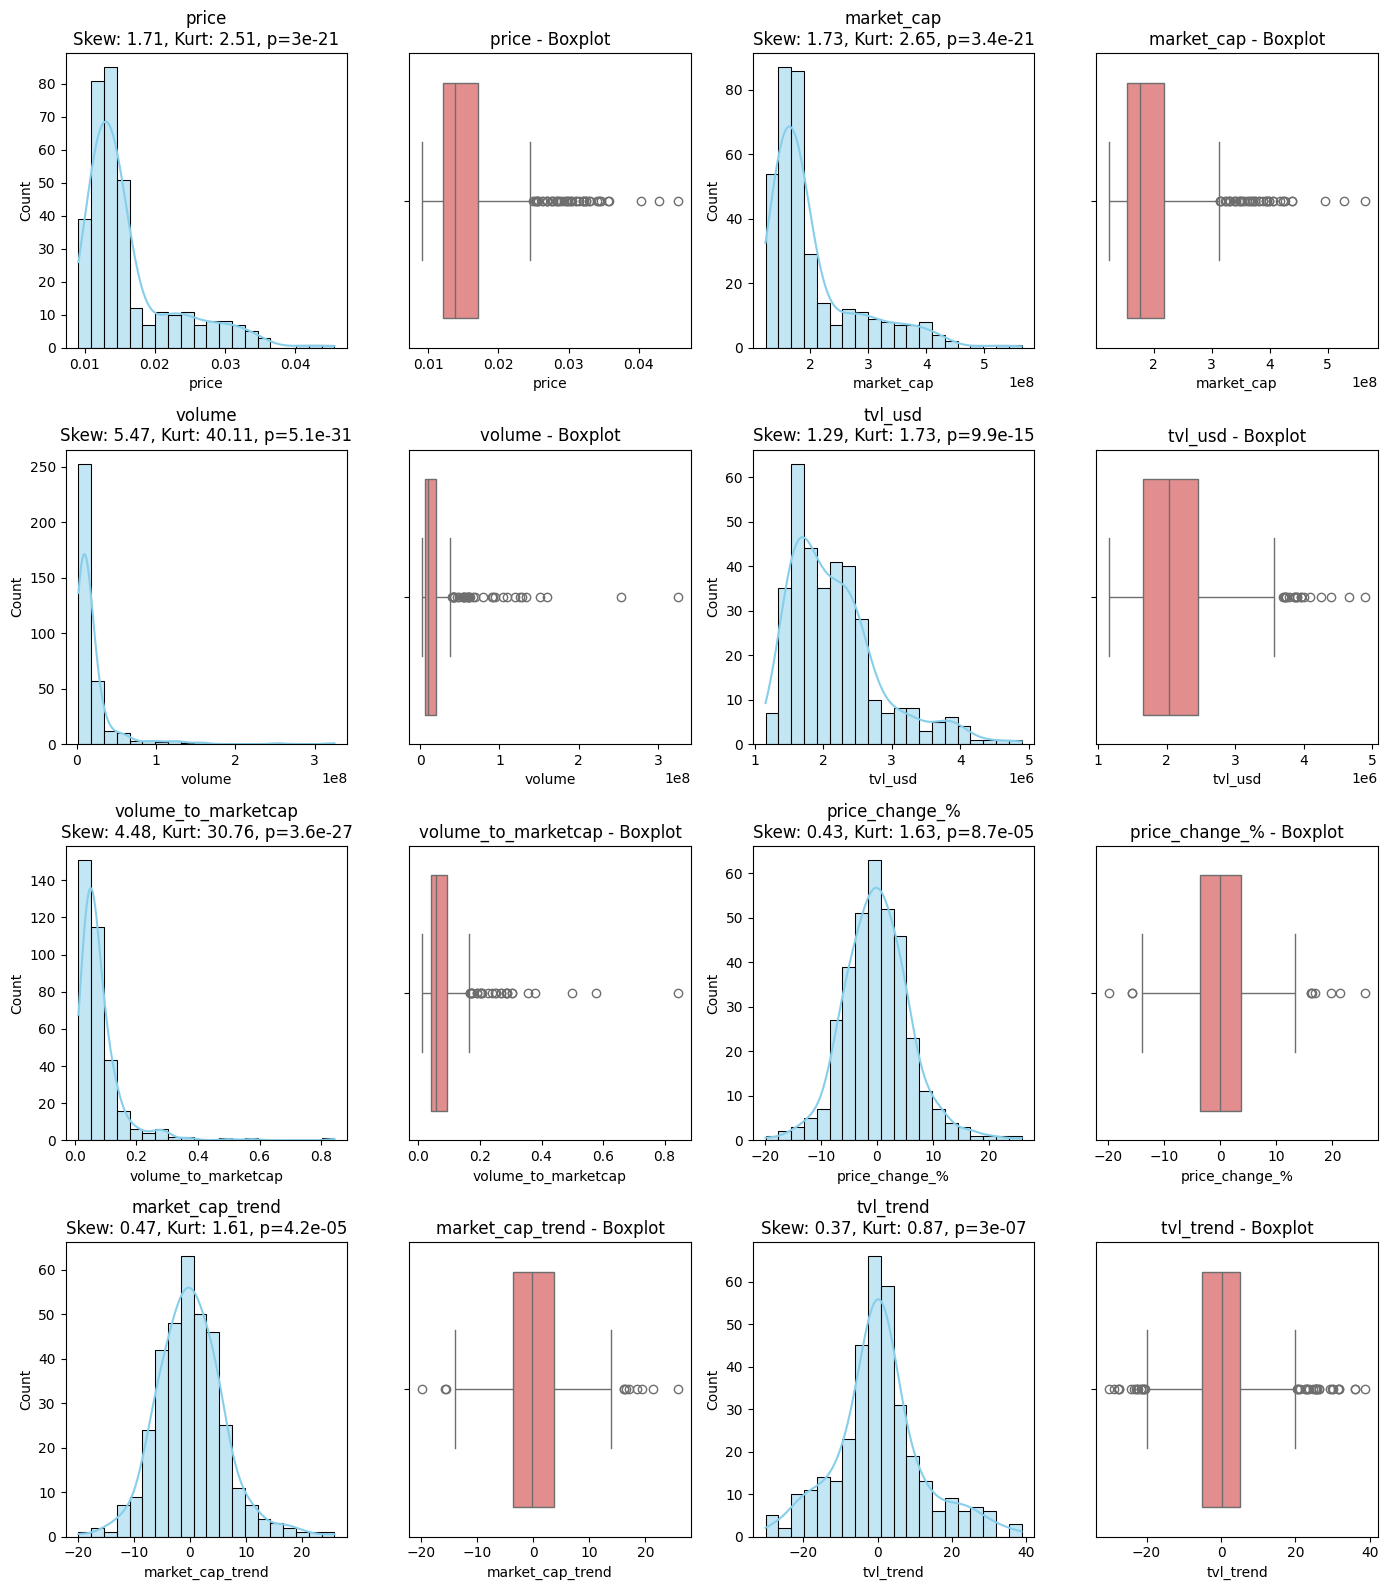

### Distribución de variables numéricas para Kadena


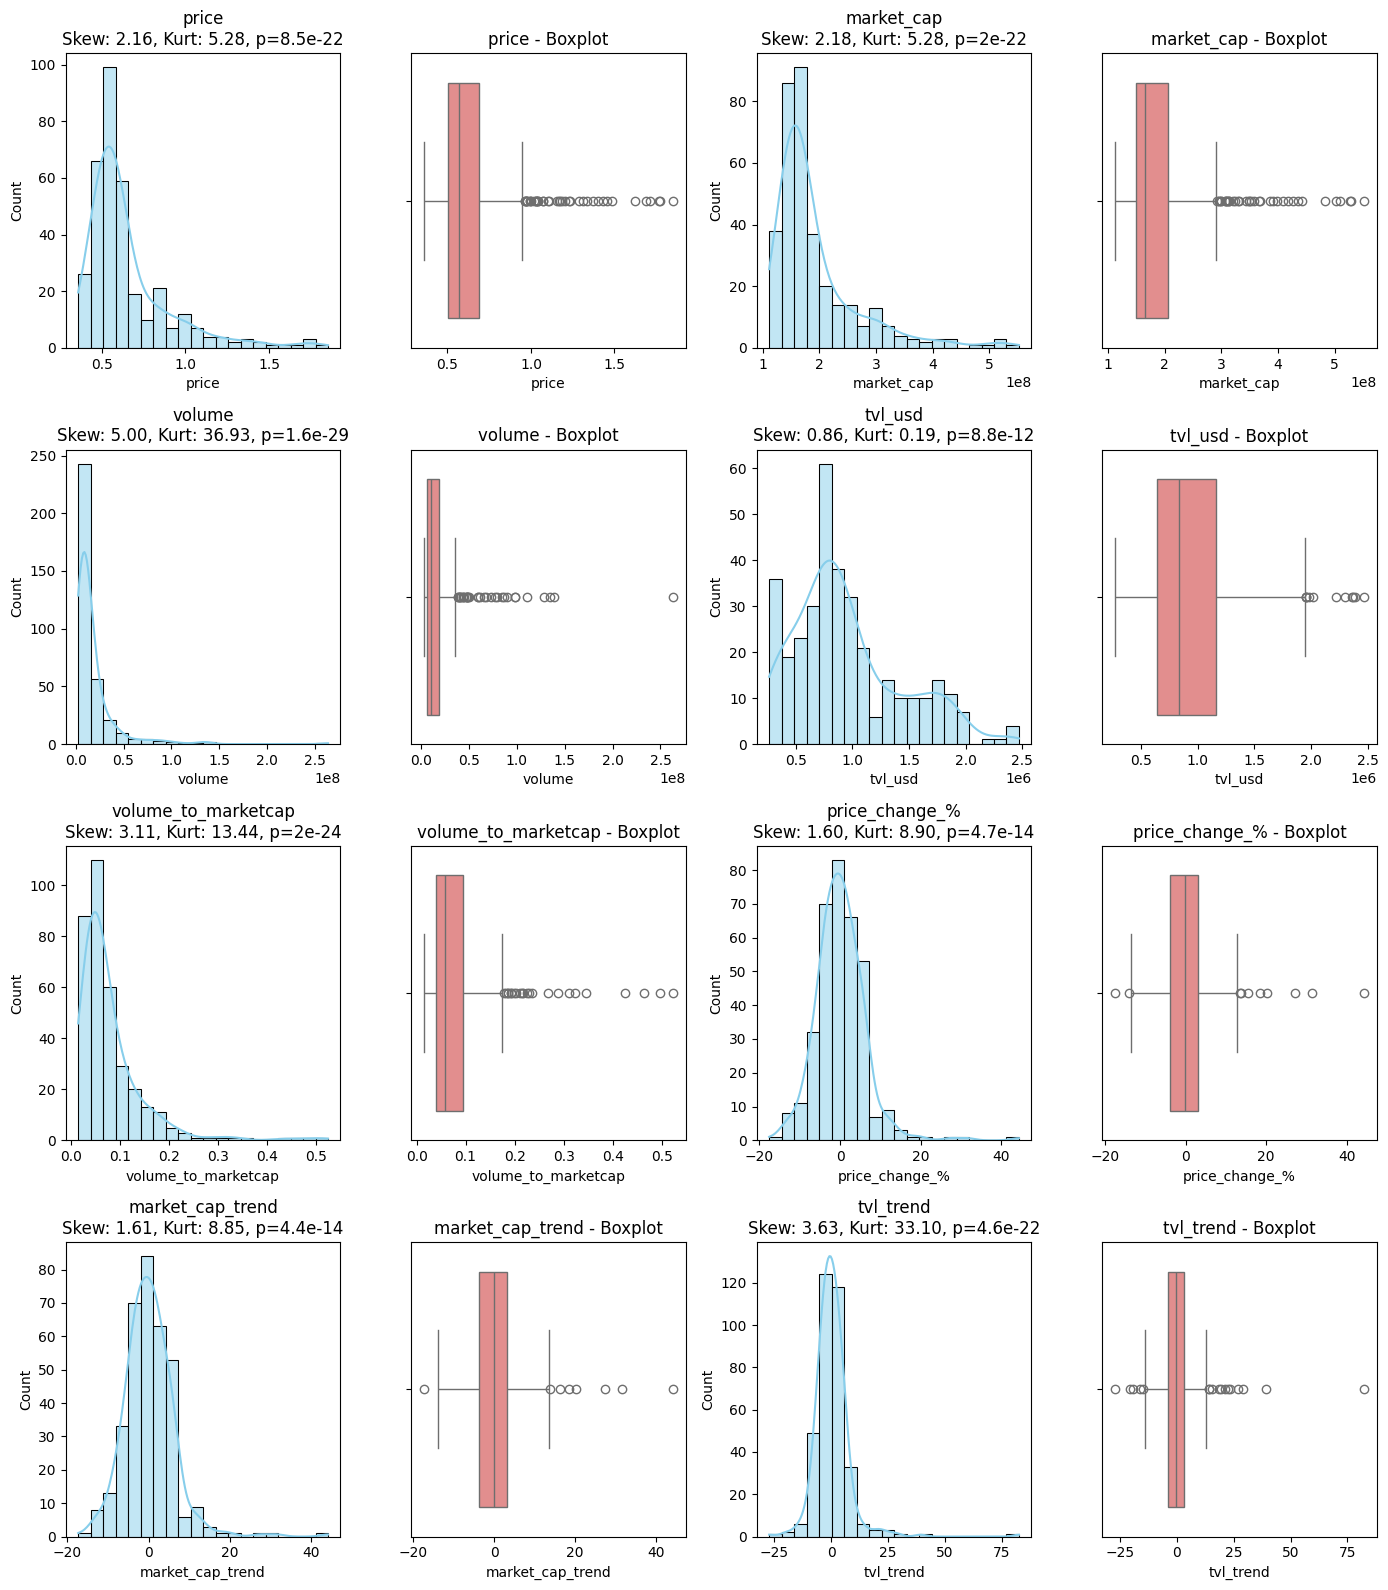

### Distribución de variables numéricas para Kava


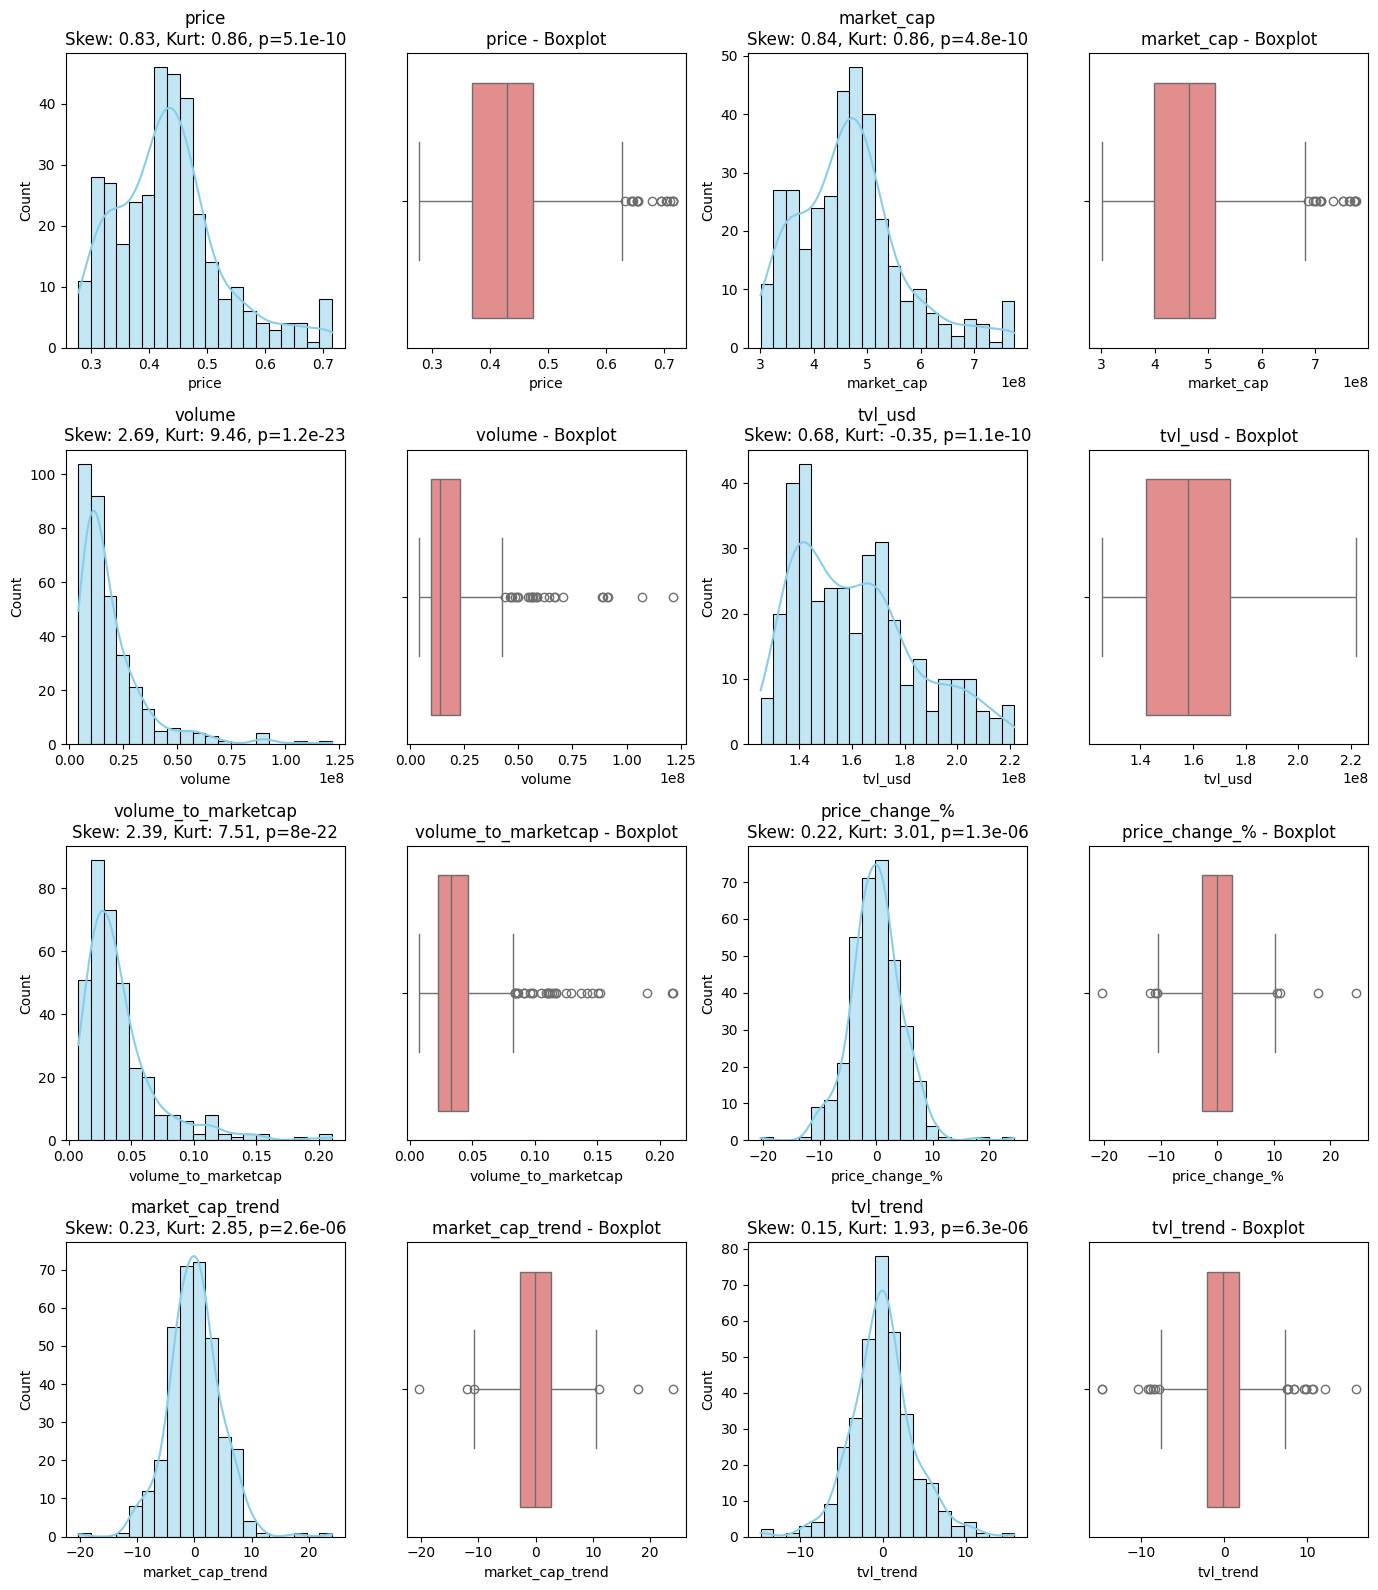

### Distribución de variables numéricas para Nolus


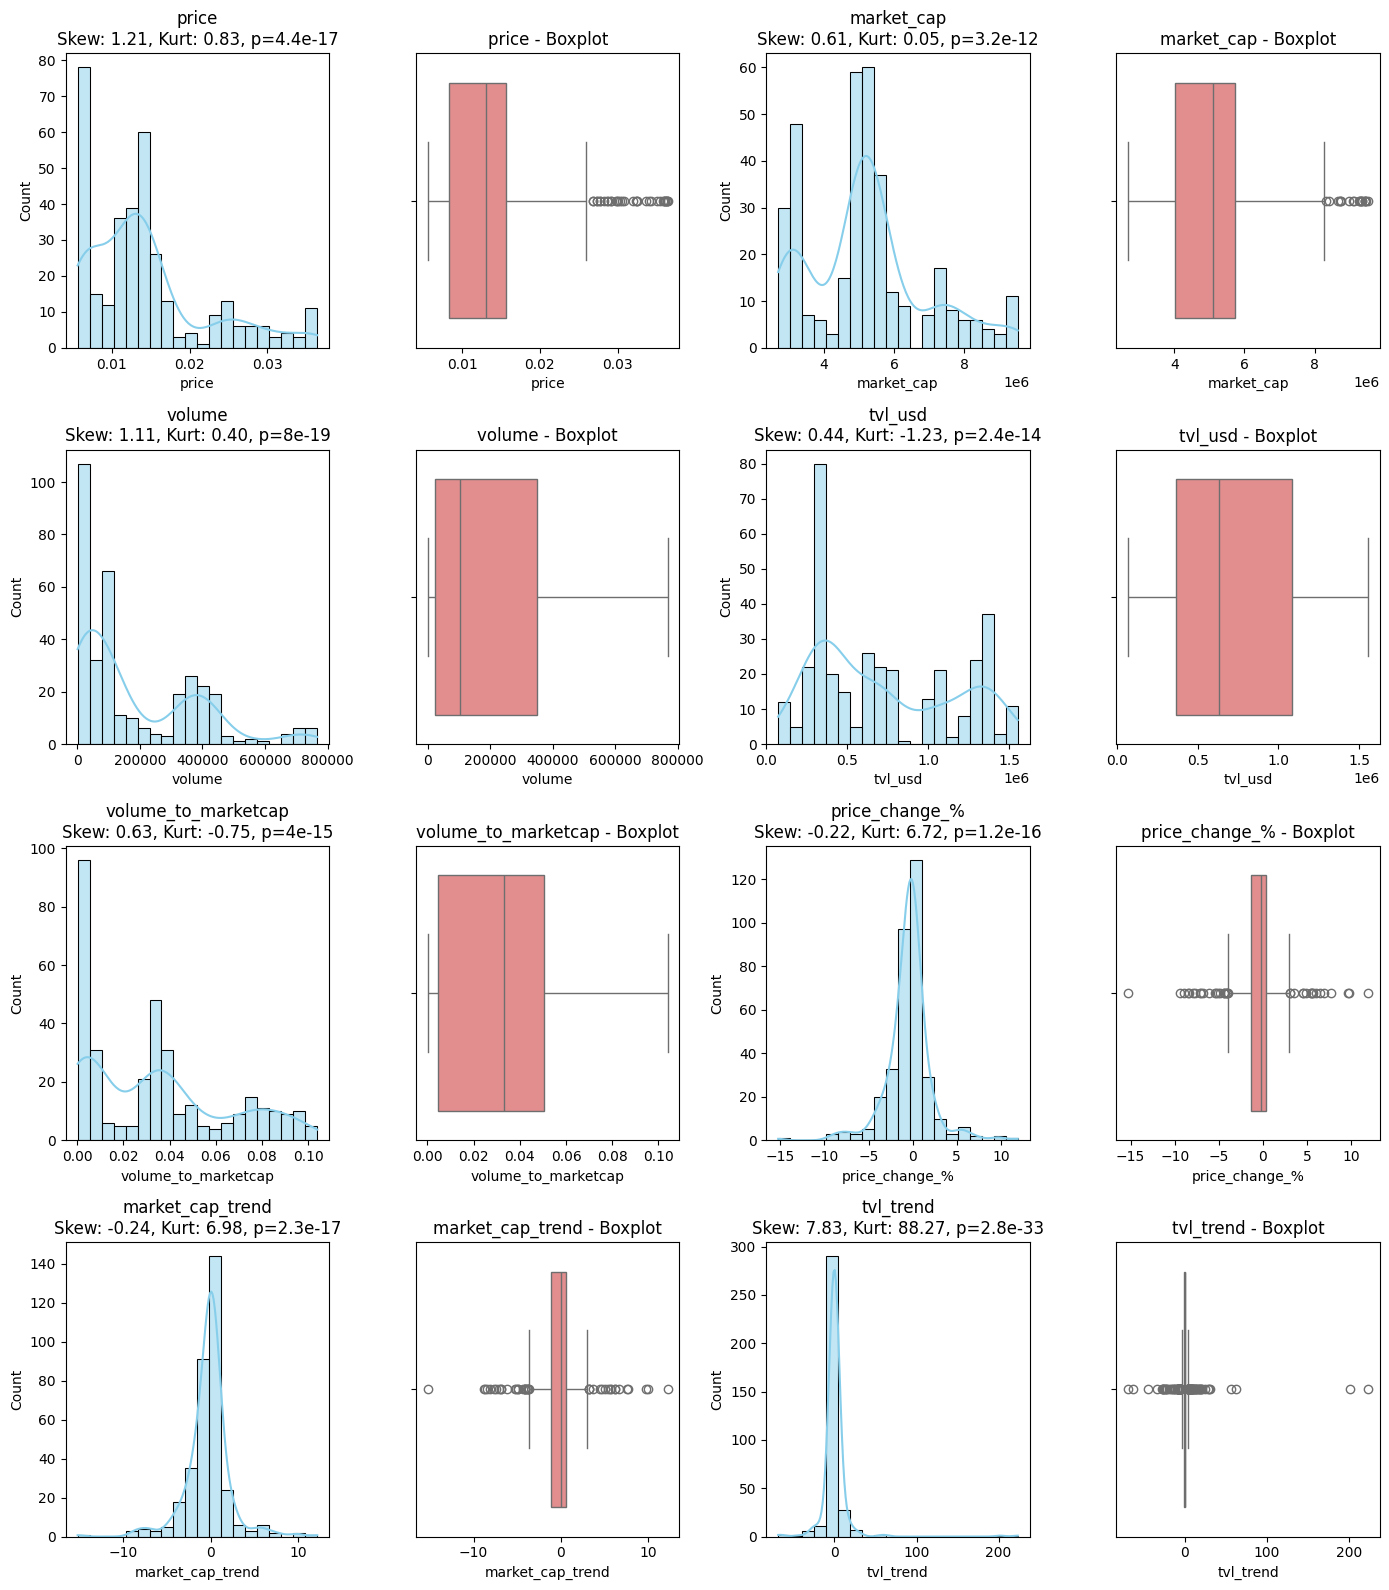

### Distribución de variables numéricas para Stargaze


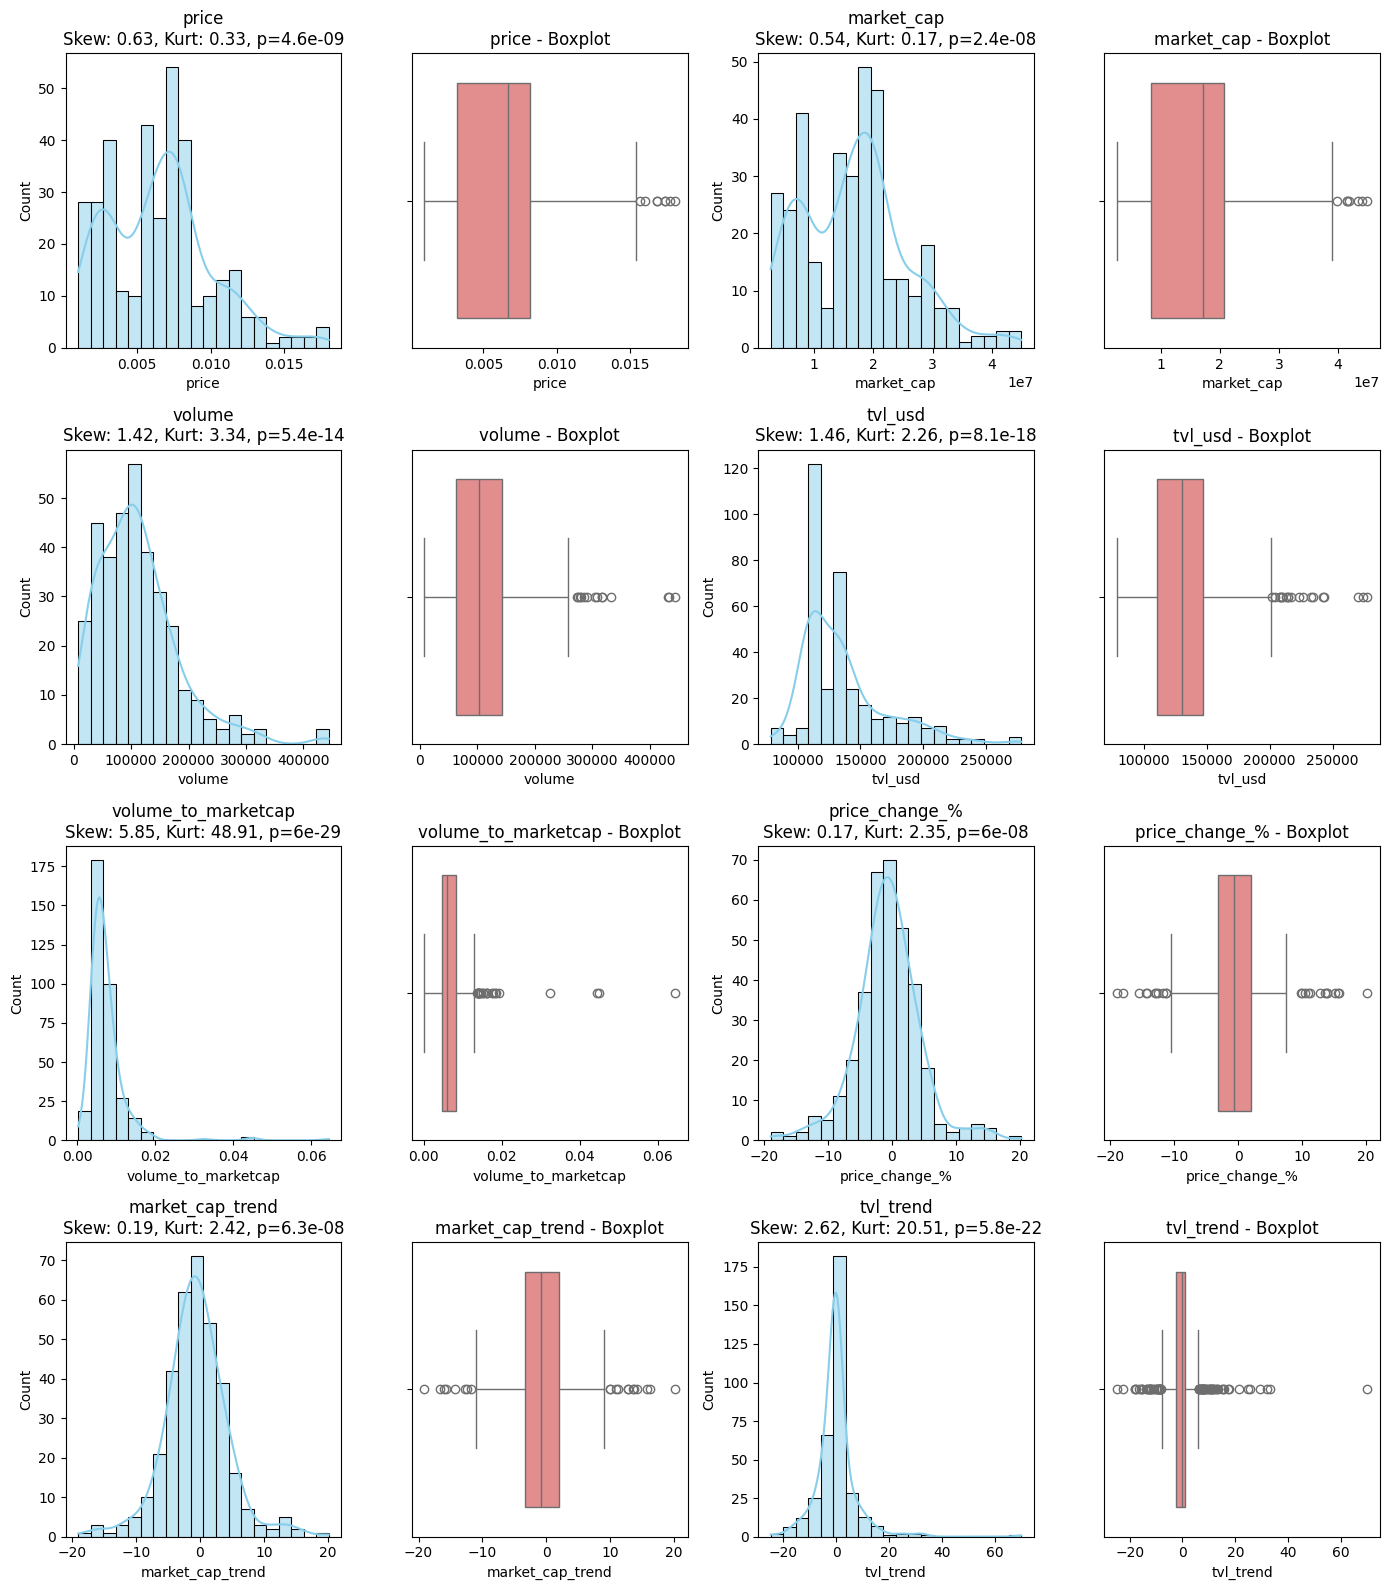

In [68]:
token_name = eda_data["name"].unique()
for token in token_name:
    print(f"### Distribución de variables numéricas para {token}")
    token_data = eda_data[eda_data["name"] == token]
    plot_numeric_distributions(token_data, numeric_columns)


Análisis de la distribución de variables numéticas:

Moneda Harmony:

price: Posee una alta asimetría positiva, una kurtosis medianamente alta, así como un pvalue muchísimos menor a 0.05. Esto lo podemos observar en el histograma puesto a que los bins son mas altos en los valores más bajos y la cola está a la derecha, por otro lado, la concentración es mucho mayor en el extremo izquierdo a comparación del derecho donde la cola es ligera, es por ello que nuestra kurtosis se acerca a 3.

market_cap: ...

Por lo tanto en la fase de preprocesamiento se realizarán transformaciones logarítmicas y suavizado de outliers para contrarestar la asimetría fuerte y las colas pesadas

## Deteccion de outliers estacionales

In [69]:
# Revisar las columnas disponibles para identificar información temporal
print("Columnas disponibles:")
print(eda_data.columns.tolist())
print("\nTipos de datos:")
print(eda_data.dtypes)

Columnas disponibles:
['date', 'price', 'market_cap', 'volume', 'token', 'name', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend']

Tipos de datos:
date                    object
price                  float64
market_cap             float64
volume                 float64
token                   object
name                    object
tvl_usd                  int64
volume_to_marketcap    float64
price_change_%         float64
market_cap_trend       float64
tvl_trend              float64
dtype: object


In [12]:
# Convertir la columna date a datetime
eda_data['date'] = pd.to_datetime(eda_data['date'])

# Examinar el rango temporal
print(f"Rango temporal del dataset:")
print(f"Fecha inicial: {eda_data['date'].min()}")
print(f"Fecha final: {eda_data['date'].max()}")
print(f"Total de días: {(eda_data['date'].max() - eda_data['date'].min()).days}")

# Crear columnas auxiliares para el análisis temporal
eda_data['year'] = eda_data['date'].dt.year
eda_data['month'] = eda_data['date'].dt.month
eda_data['quarter'] = eda_data['date'].dt.quarter
eda_data['month_name'] = eda_data['date'].dt.strftime('%B')

print(f"\nAños disponibles: {sorted(eda_data['year'].unique())}")
print(f"Meses disponibles: {sorted(eda_data['month'].unique())}")
print(f"Trimestres disponibles: {sorted(eda_data['quarter'].unique())}")

Rango temporal del dataset:
Fecha inicial: 2024-06-01 00:00:00
Fecha final: 2025-05-14 00:00:00
Total de días: 347

Años disponibles: [2024, 2025]
Meses disponibles: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Trimestres disponibles: [1, 2, 3, 4]


In [13]:
def detect_outliers_iqr(data, column):
    """
    Detecta outliers usando el método IQR (Rango Intercuartílico)
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites para outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificar outliers
    outliers_mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    
    return outliers_mask, lower_bound, upper_bound

def analyze_seasonal_outliers(data, numeric_columns, method='iqr'):
    """
    Analiza la estacionalidad de outliers para todas las variables numéricas
    """
    results = {}
    
    for column in numeric_columns:
        if column in ['year', 'month', 'quarter']:  # Excluir columnas temporales
            continue
            
        print(f"\n=== Análisis de outliers para: {column} ===")
        
        # Detectar outliers
        outliers_mask, lower_bound, upper_bound = detect_outliers_iqr(data, column)
        outliers_data = data[outliers_mask].copy()
        
        print(f"Total de outliers detectados: {len(outliers_data)}")
        print(f"Porcentaje de outliers: {len(outliers_data)/len(data)*100:.2f}%")
        
        if len(outliers_data) == 0:
            print("No se detectaron outliers para esta variable.")
            continue
            
        # Análisis mensual
        monthly_counts = outliers_data['month'].value_counts().sort_index()
        total_outliers = len(outliers_data)
        monthly_percentages = (monthly_counts / total_outliers * 100).round(2)
        
        # Análisis trimestral
        quarterly_counts = outliers_data['quarter'].value_counts().sort_index()
        quarterly_percentages = (quarterly_counts / total_outliers * 100).round(2)
        
        # Determinar estacionalidad
        max_monthly_percentage = monthly_percentages.max()
        max_quarterly_percentage = quarterly_percentages.max()
        
        is_seasonal_monthly = max_monthly_percentage >= 30
        is_seasonal_quarterly = max_quarterly_percentage >= 40
        
        # Identificar período dominante
        dominant_month = monthly_percentages.idxmax()
        dominant_quarter = quarterly_percentages.idxmax()
        
        # Mapear números de mes a nombres
        month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 
                      5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
                      9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
        
        print(f"\n--- Distribución mensual de outliers ---")
        for month, count in monthly_counts.items():
            percentage = monthly_percentages[month]
            print(f"{month_names[month]}: {count} outliers ({percentage}%)")
        
        print(f"\n--- Distribución trimestral de outliers ---")
        for quarter, count in quarterly_counts.items():
            percentage = quarterly_percentages[quarter]
            print(f"Trimestre {quarter}: {count} outliers ({percentage}%)")
        
        print(f"\n--- Análisis de estacionalidad ---")
        print(f"Mes con mayor concentración: {month_names[dominant_month]} ({max_monthly_percentage}%)")
        print(f"¿Estacional por mes? {is_seasonal_monthly} (umbral: ≥30%)")
        print(f"Trimestre con mayor concentración: {dominant_quarter} ({max_quarterly_percentage}%)")
        print(f"¿Estacional por trimestre? {is_seasonal_quarterly} (umbral: ≥40%)")
        
        # Guardar resultados
        results[column] = {
            'outliers_count': total_outliers,
            'outliers_percentage': len(outliers_data)/len(data)*100,
            'monthly_distribution': monthly_counts.to_dict(),
            'monthly_percentages': monthly_percentages.to_dict(),
            'quarterly_distribution': quarterly_counts.to_dict(),
            'quarterly_percentages': quarterly_percentages.to_dict(),
            'dominant_month': dominant_month,
            'dominant_quarter': dominant_quarter,
            'max_monthly_percentage': max_monthly_percentage,
            'max_quarterly_percentage': max_quarterly_percentage,
            'is_seasonal_monthly': is_seasonal_monthly,
            'is_seasonal_quarterly': is_seasonal_quarterly,
            'is_seasonal': is_seasonal_monthly or is_seasonal_quarterly,
            'outliers_indices': outliers_data.index.tolist(),
            'bounds': {'lower': lower_bound, 'upper': upper_bound}
        }
    
    return results

# Definir las variables numéricas a analizar (excluyendo las temporales)
variables_to_analyze = ['price', 'market_cap', 'volume', 'tvl_usd', 
                       'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend']



In [14]:
# Ejecutar el análisis de estacionalidad
seasonal_analysis_results = analyze_seasonal_outliers(eda_data, variables_to_analyze)


=== Análisis de outliers para: price ===
Total de outliers detectados: 21
Porcentaje de outliers: 1.21%

--- Distribución mensual de outliers ---
Noviembre: 3 outliers (14.29%)
Diciembre: 18 outliers (85.71%)

--- Distribución trimestral de outliers ---
Trimestre 4: 21 outliers (100.0%)

--- Análisis de estacionalidad ---
Mes con mayor concentración: Diciembre (85.71%)
¿Estacional por mes? True (umbral: ≥30%)
Trimestre con mayor concentración: 4 (100.0%)
¿Estacional por trimestre? True (umbral: ≥40%)

=== Análisis de outliers para: market_cap ===
Total de outliers detectados: 9
Porcentaje de outliers: 0.52%

--- Distribución mensual de outliers ---
Junio: 3 outliers (33.33%)
Diciembre: 6 outliers (66.67%)

--- Distribución trimestral de outliers ---
Trimestre 2: 3 outliers (33.33%)
Trimestre 4: 6 outliers (66.67%)

--- Análisis de estacionalidad ---
Mes con mayor concentración: Diciembre (66.67%)
¿Estacional por mes? True (umbral: ≥30%)
Trimestre con mayor concentración: 4 (66.67%)
¿E

In [15]:
print("total de outliears en el dataset:")


total de outliears en el dataset:


In [16]:
print(f"Que porcentaje representan los outliers de cada variable de los outliers totales: ")

Que porcentaje representan los outliers de cada variable de los outliers totales: 


In [17]:
# Resumen general de distribución de outliers
print("\n" + "="*80)
print("RESUMEN GENERAL DE DISTRIBUCIÓN DE OUTLIERS")
print("="*80)

# Mapear números de mes a nombres
month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 
              5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
              9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}

# Compilar todos los outliers de todas las variables
all_outliers_monthly = {}
all_outliers_quarterly = {}
total_outliers_count = 0
seasonal_variables = []

for var, result in seasonal_analysis_results.items():
    total_outliers_count += result['outliers_count']
    
    # Sumar outliers por mes
    for month, count in result['monthly_distribution'].items():
        all_outliers_monthly[month] = all_outliers_monthly.get(month, 0) + count
    
    # Sumar outliers por trimestre
    for quarter, count in result['quarterly_distribution'].items():
        all_outliers_quarterly[quarter] = all_outliers_quarterly.get(quarter, 0) + count
    
    # Identificar variables estacionales
    if result['is_seasonal']:
        seasonal_variables.append(var)

# Calcular porcentajes generales
monthly_percentages = {month: (count / total_outliers_count * 100) for month, count in all_outliers_monthly.items()}
quarterly_percentages = {quarter: (count / total_outliers_count * 100) for quarter, count in all_outliers_quarterly.items()}

print(f"Total de outliers detectados: {total_outliers_count}")
print(f"Variables analizadas: {len(seasonal_analysis_results)}")

print(f"\nDISTRIBUCIÓN MENSUAL DE OUTLIERS:")
for month in range(1, 13):
    count = all_outliers_monthly.get(month, 0)
    percentage = monthly_percentages.get(month, 0)
    if count > 0:
        status = "*" if percentage >= 30 else " "
        print(f"  {status} {month_names[month]:12}: {count:4d} outliers ({percentage:5.1f}%)")

print(f"\nDISTRIBUCIÓN TRIMESTRAL DE OUTLIERS:")
for quarter in range(1, 5):
    count = all_outliers_quarterly.get(quarter, 0)
    percentage = quarterly_percentages.get(quarter, 0)
    if count > 0:
        status = "*" if percentage >= 40 else " "
        print(f"  {status} Trimestre {quarter}: {count:4d} outliers ({percentage:5.1f}%)")

# Determinar estacionalidad general
max_monthly_percentage = max(monthly_percentages.values()) if monthly_percentages else 0
max_quarterly_percentage = max(quarterly_percentages.values()) if quarterly_percentages else 0

print(f"\n{'='*80}")
print(f"ANÁLISIS DE ESTACIONALIDAD")
print(f"{'='*80}")
print(f"Variables con estacionalidad individual: {len(seasonal_variables)}")
print(f"Concentración mensual máxima: {max_monthly_percentage:.1f}%")
print(f"Concentración trimestral máxima: {max_quarterly_percentage:.1f}%")

is_seasonal_general = max_monthly_percentage >= 30 or max_quarterly_percentage >= 40

if is_seasonal_general:
    print(f"\nRECOMENDAGIÓN: DIVIDIR EL DATASET")
    print(f"Se detectó concentración estacional significativa en los outliers.")
    
    if max_monthly_percentage >= 30:
        dominant_month = max(monthly_percentages, key=monthly_percentages.get)
        print(f"Mes con mayor concentración: {month_names[dominant_month]} ({max_monthly_percentage:.1f}%)")
    
    if max_quarterly_percentage >= 40:
        dominant_quarter = max(quarterly_percentages, key=quarterly_percentages.get)
        print(f"Trimestre con mayor concentración: Q{dominant_quarter} ({max_quarterly_percentage:.1f}%)")
else:
    print(f"\nRECOMENDAGIÓN: NO DIVIDIR EL DATASET")
    print(f"No se detectó concentración estacional significativa.")

print(f"\nUmbrales utilizados: Mensual ≥30% | Trimestral ≥40%")
print(f"* = Supera el umbral de estacionalidad")


RESUMEN GENERAL DE DISTRIBUCIÓN DE OUTLIERS
Total de outliers detectados: 1013
Variables analizadas: 8

DISTRIBUCIÓN MENSUAL DE OUTLIERS:
    Enero       :  102 outliers ( 10.1%)
    Febrero     :   77 outliers (  7.6%)
    Marzo       :   62 outliers (  6.1%)
    Abril       :   66 outliers (  6.5%)
    Mayo        :   38 outliers (  3.8%)
    Junio       :   77 outliers (  7.6%)
    Julio       :   65 outliers (  6.4%)
    Agosto      :   65 outliers (  6.4%)
    Septiembre  :   57 outliers (  5.6%)
    Octubre     :   57 outliers (  5.6%)
    Noviembre   :  150 outliers ( 14.8%)
    Diciembre   :  197 outliers ( 19.4%)

DISTRIBUCIÓN TRIMESTRAL DE OUTLIERS:
    Trimestre 1:  241 outliers ( 23.8%)
    Trimestre 2:  181 outliers ( 17.9%)
    Trimestre 3:  187 outliers ( 18.5%)
    Trimestre 4:  404 outliers ( 39.9%)

ANÁLISIS DE ESTACIONALIDAD
Variables con estacionalidad individual: 4
Concentración mensual máxima: 19.4%
Concentración trimestral máxima: 39.9%

RECOMENDAGIÓN: NO DIVIDI

Creando visualizaciones de distribución temporal de outliers por token...
Analizando 5 tokens: Harmony, Kadena, Kava, Nolus, Stargaze

=== Visualizaciones para Harmony ===


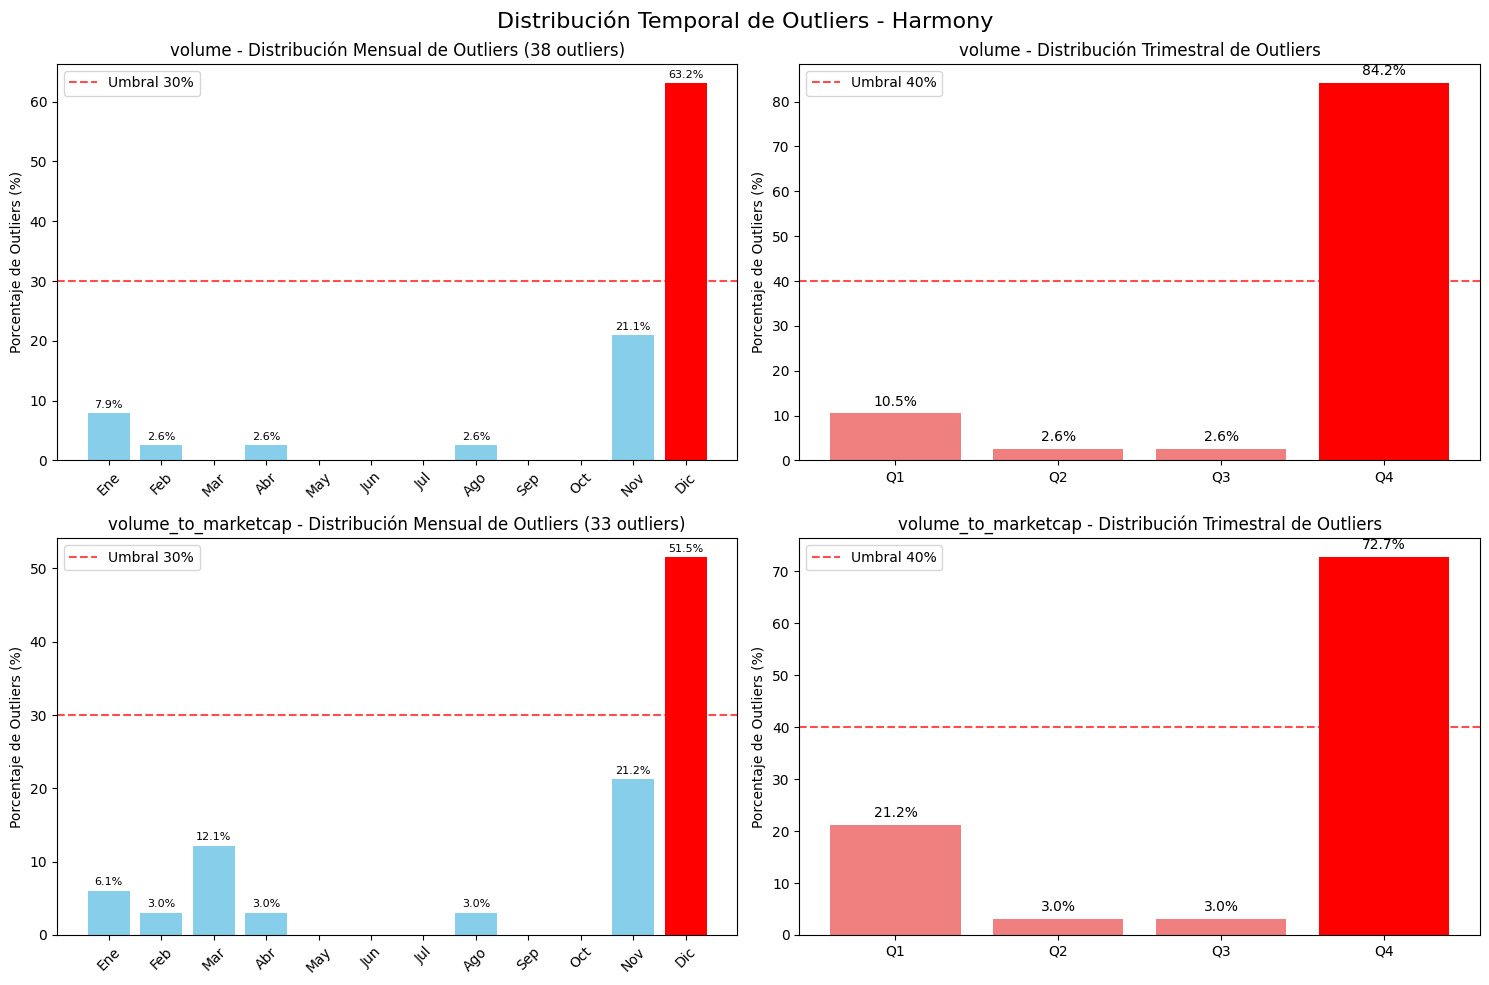


=== Visualizaciones para Kadena ===


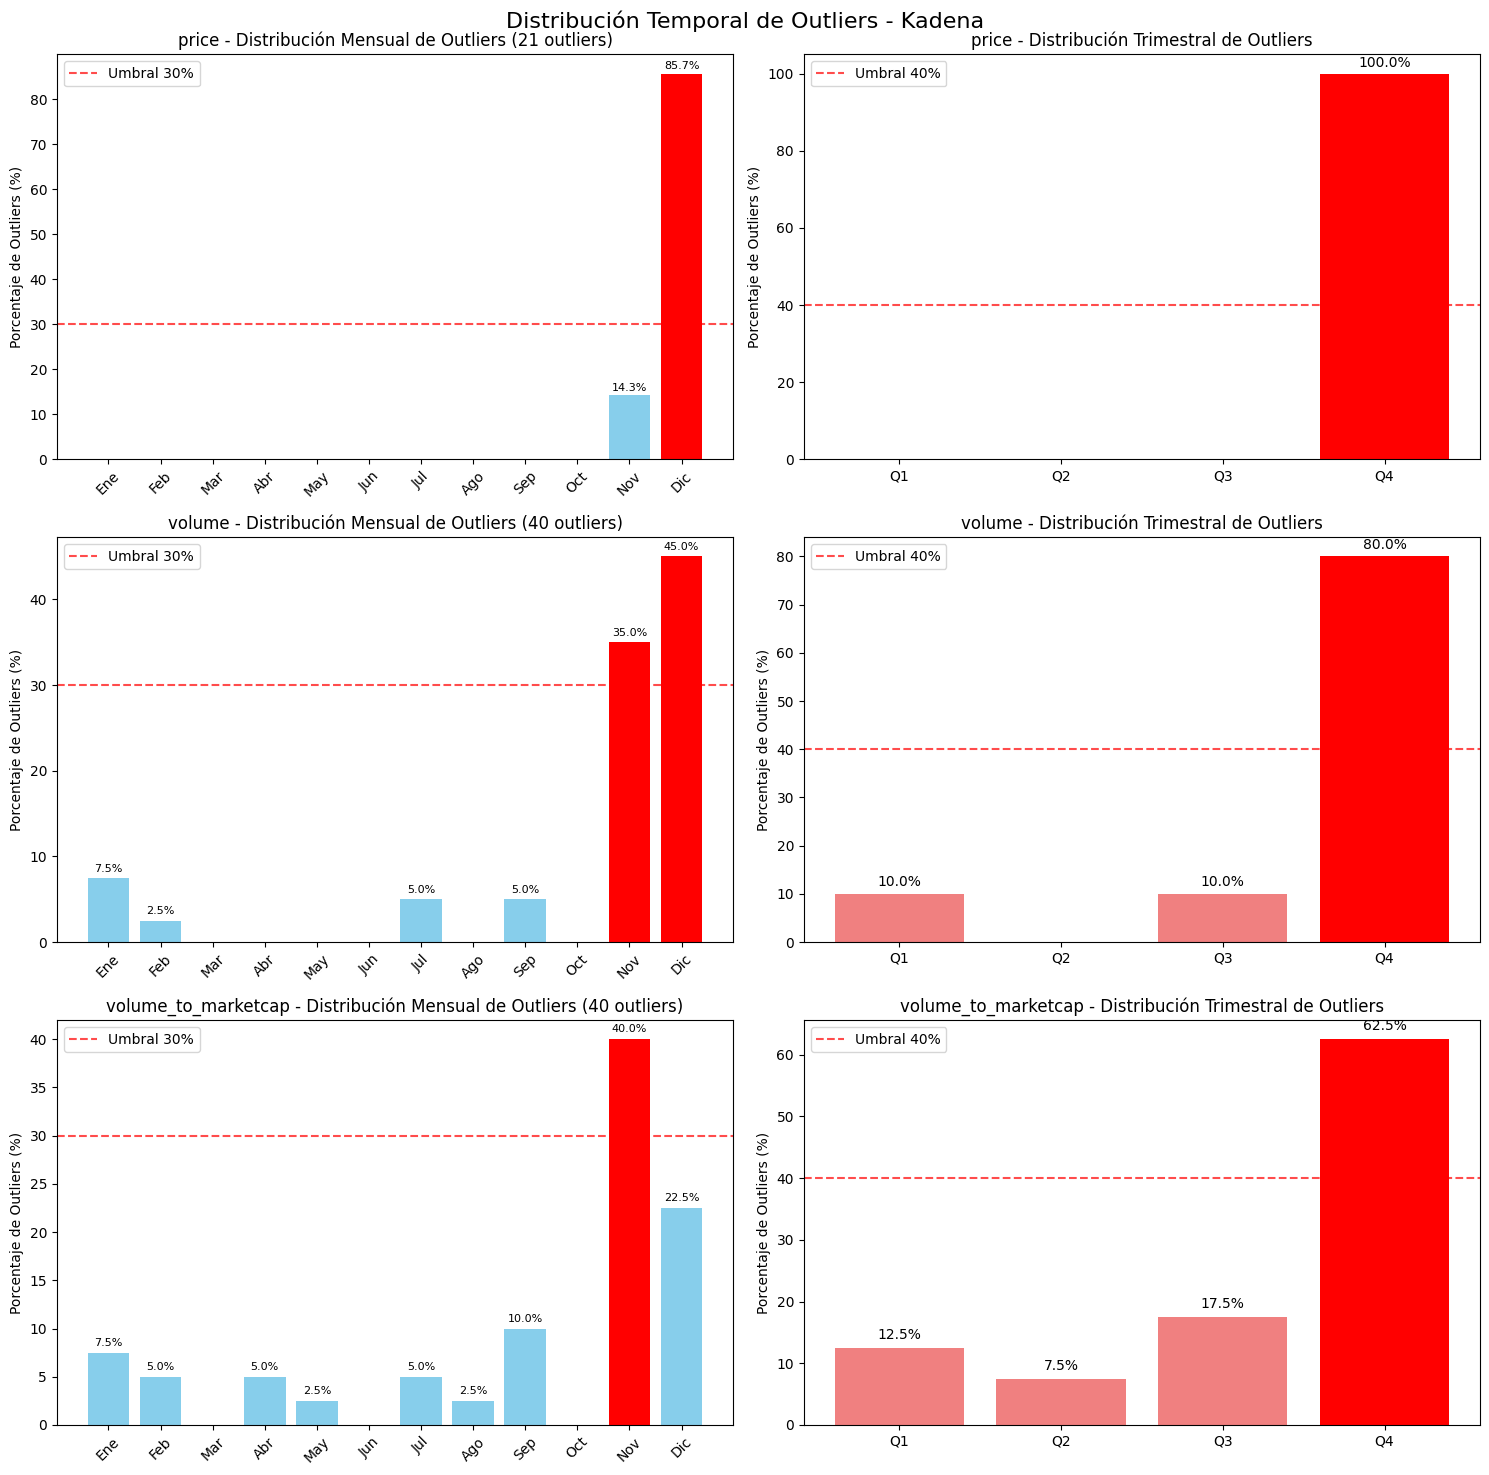


=== Visualizaciones para Kava ===


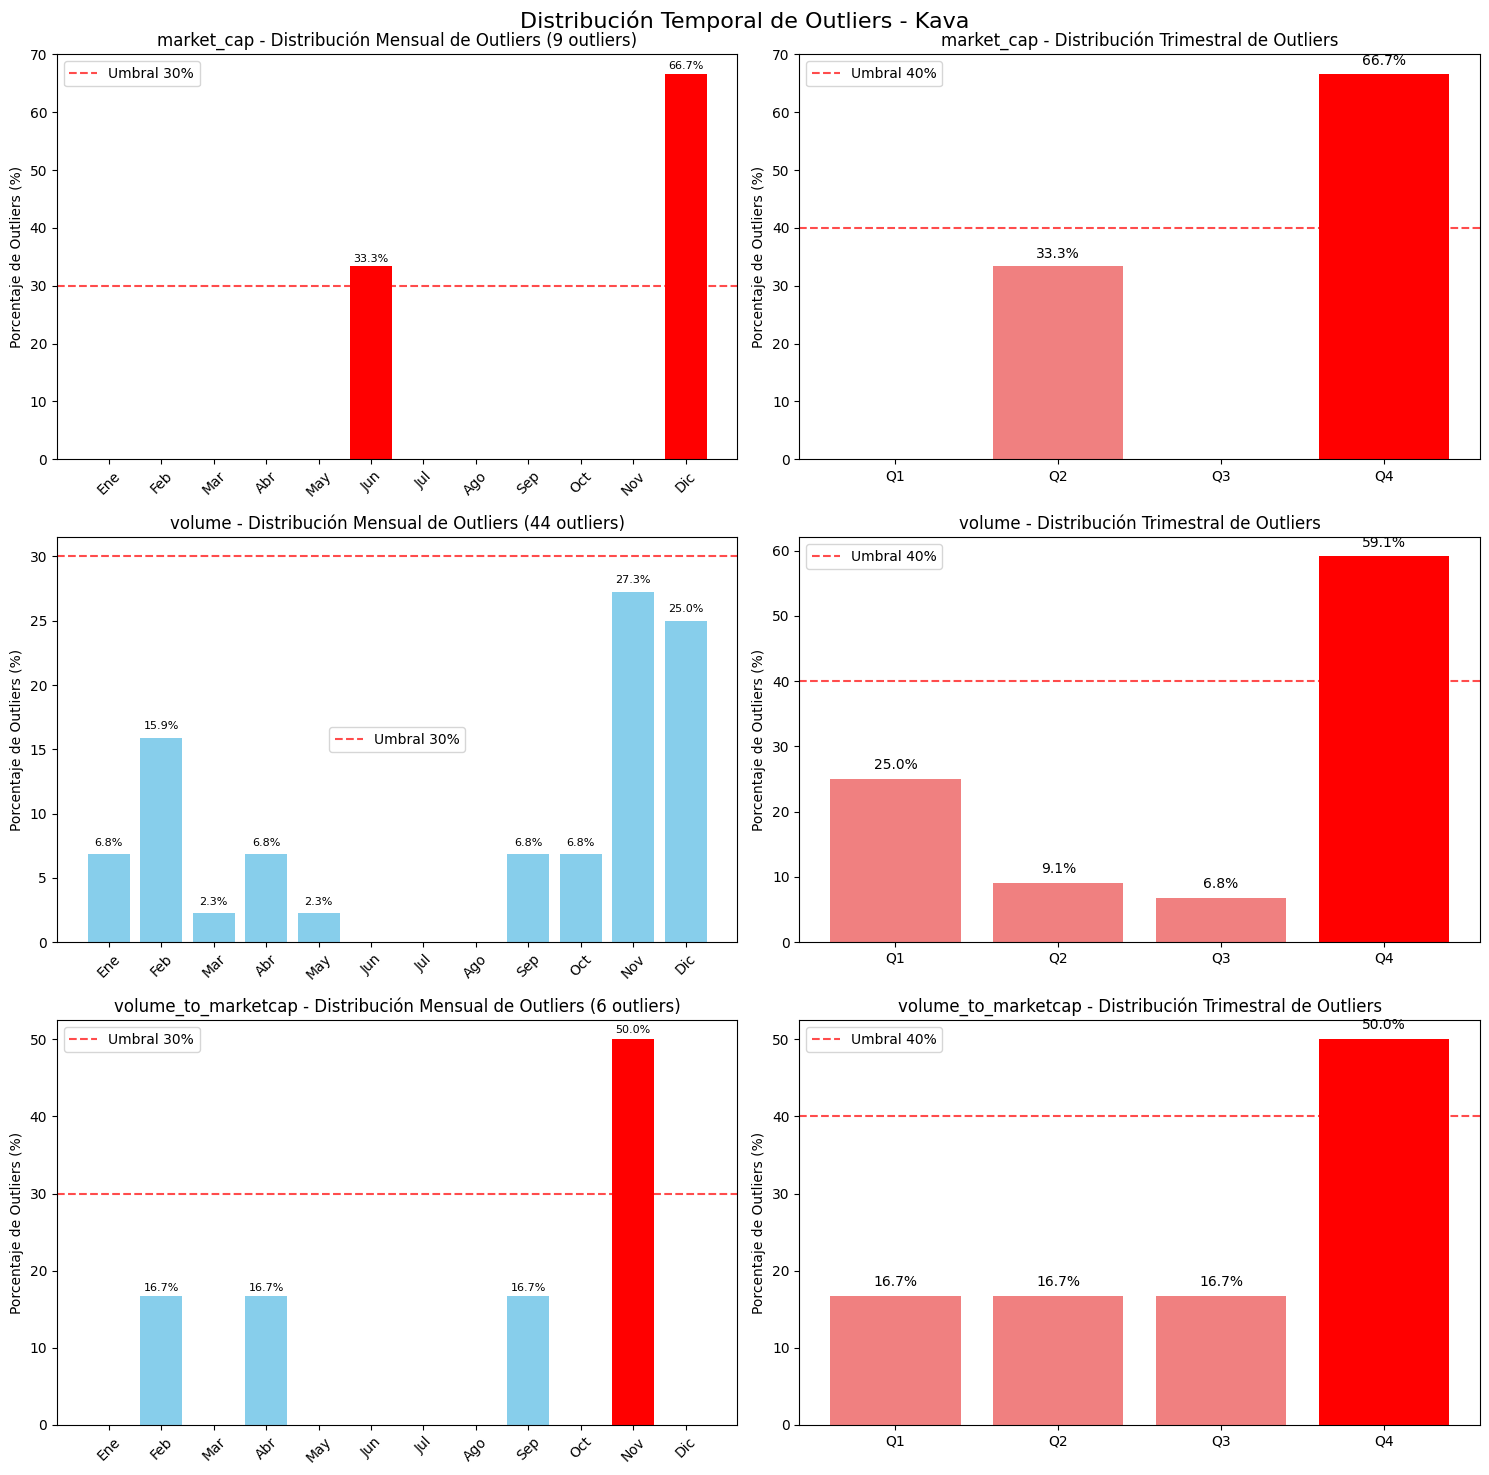


=== Visualizaciones para Nolus ===
No hay variables con outliers estacionales para Nolus

=== Visualizaciones para Stargaze ===
No hay variables con outliers estacionales para Stargaze


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

def plot_seasonal_outliers(data, results, variables_to_plot=None):
    """
    Crea visualizaciones de la distribución temporal de outliers divididas por token
    """
    if variables_to_plot is None:
        variables_to_plot = [var for var in results.keys() if results[var]['is_seasonal']]
    
    if not variables_to_plot:
        print("No hay variables con estacionalidad para visualizar.")
        return
    
    # Obtener tokens únicos
    tokens = data['name'].unique()
    print(f"Analizando {len(tokens)} tokens: {', '.join(tokens)}")
    
    # Configurar el estilo
    plt.style.use('default')
    
    month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                   'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    
    # Para cada token, crear visualizaciones
    for token in tokens:
        print(f"\n=== Visualizaciones para {token} ===")
        token_data = data[data['name'] == token]
        
        # Filtrar variables que tienen outliers para este token
        token_variables = []
        for var in variables_to_plot:
            # Verificar si hay outliers para esta variable en este token
            outliers_indices = results[var]['outliers_indices']
            token_outliers = [idx for idx in outliers_indices if idx in token_data.index]
            if token_outliers:
                token_variables.append(var)
        
        if not token_variables:
            print(f"No hay variables con outliers estacionales para {token}")
            continue
        
        # Crear subplots para este token
        n_vars = len(token_variables)
        fig, axes = plt.subplots(n_vars, 2, figsize=(15, 5*n_vars))
        fig.suptitle(f'Distribución Temporal de Outliers - {token}', fontsize=16, y=0.98)
        
        if n_vars == 1:
            axes = axes.reshape(1, -1)
        
        for i, var in enumerate(token_variables):
            # Obtener outliers específicos del token
            outliers_indices = results[var]['outliers_indices']
            token_outliers_indices = [idx for idx in outliers_indices if idx in token_data.index]
            token_outliers_data = data.loc[token_outliers_indices]
            
            if len(token_outliers_data) == 0:
                continue
            
            # Análisis mensual para el token
            monthly_counts = token_outliers_data['month'].value_counts().sort_index()
            total_token_outliers = len(token_outliers_data)
            monthly_percentages = (monthly_counts / total_token_outliers * 100).round(2)
            
            # Análisis trimestral para el token
            quarterly_counts = token_outliers_data['quarter'].value_counts().sort_index()
            quarterly_percentages = (quarterly_counts / total_token_outliers * 100).round(2)
            
            # Gráfico mensual
            monthly_data = [monthly_percentages.get(month, 0) for month in range(1, 13)]
            bars1 = axes[i, 0].bar(month_names, monthly_data, 
                                  color=['red' if x >= 30 else 'skyblue' for x in monthly_data])
            axes[i, 0].set_title(f'{var} - Distribución Mensual de Outliers ({total_token_outliers} outliers)')
            axes[i, 0].set_ylabel('Porcentaje de Outliers (%)')
            axes[i, 0].axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Umbral 30%')
            axes[i, 0].legend()
            axes[i, 0].tick_params(axis='x', rotation=45)
            
            # Agregar valores encima de las barras
            for bar, value in zip(bars1, monthly_data):
                if value > 0:
                    axes[i, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                                   f'{value:.1f}%', ha='center', va='bottom', fontsize=8)
            
            # Gráfico trimestral
            quarterly_data = [quarterly_percentages.get(quarter, 0) for quarter in range(1, 5)]
            quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']
            bars2 = axes[i, 1].bar(quarter_labels, quarterly_data,
                                  color=['red' if x >= 40 else 'lightcoral' for x in quarterly_data])
            axes[i, 1].set_title(f'{var} - Distribución Trimestral de Outliers')
            axes[i, 1].set_ylabel('Porcentaje de Outliers (%)')
            axes[i, 1].axhline(y=40, color='red', linestyle='--', alpha=0.7, label='Umbral 40%')
            axes[i, 1].legend()
            
            # Agregar valores encima de las barras
            for bar, value in zip(bars2, quarterly_data):
                if value > 0:
                    axes[i, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                                   f'{value:.1f}%', ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()

# Crear las visualizaciones divididas por token
print("Creando visualizaciones de distribución temporal de outliers por token...")
plot_seasonal_outliers(eda_data, seasonal_analysis_results)

Creando diagramas de dispersión temporal para variables numéricas...


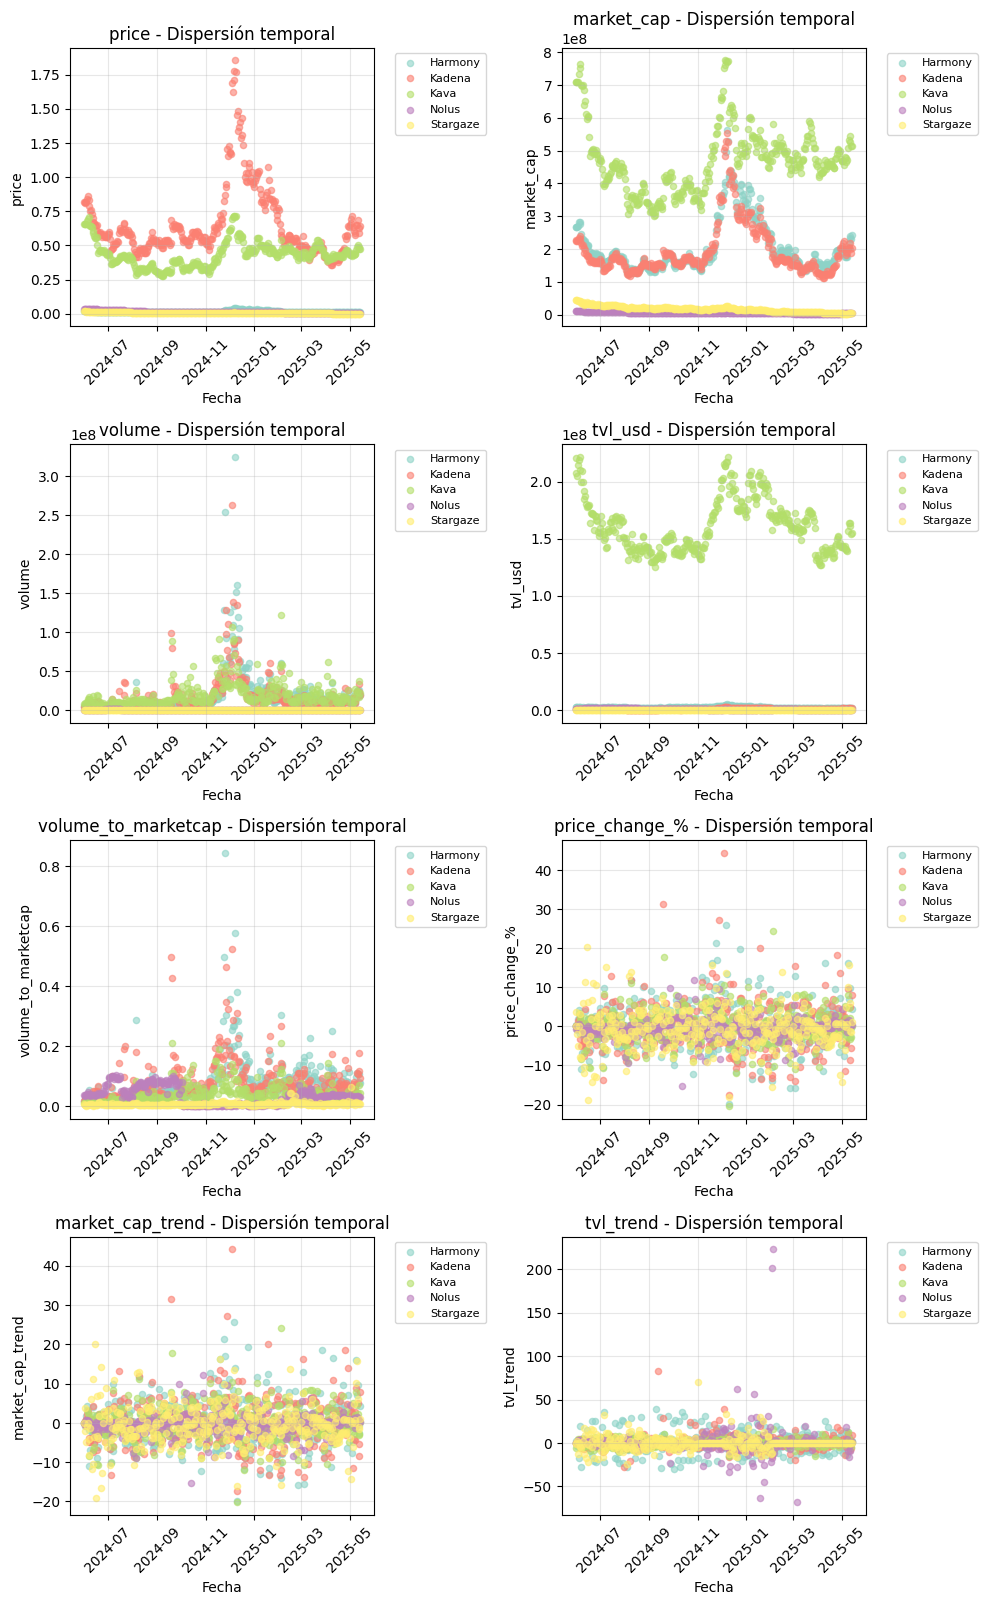

In [19]:
def plot_time_series_scatter(data, numeric_cols):
    """
    Crea diagramas de dispersión de cada variable numérica a lo largo del tiempo
    """
    cols_per_row = 2
    n = len(numeric_cols)
    rows = -(-n // cols_per_row)  # Ceiling division
    
    plt.figure(figsize=(10, rows * 4))
    
    for idx, col in enumerate(numeric_cols, 1):
        plt.subplot(rows, cols_per_row, idx)
        
        # Crear scatter plot con colores por token para mejor visualización
        tokens = data['name'].unique()
        colors = plt.cm.Set3(np.linspace(0, 1, len(tokens)))
        
        for token, color in zip(tokens, colors):
            token_data = data[data['name'] == token]
            plt.scatter(token_data['date'], token_data[col], 
                       alpha=0.6, s=20, label=token, color=color)
        
        plt.title(f'{col} - Dispersión temporal')
        plt.xlabel('Fecha')
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plotear las dispersiones temporales
print("Creando diagramas de dispersión temporal para variables numéricas...")
plot_time_series_scatter(eda_data, numeric_columns)

In [ ]:
# def create_seasonal_datasets(data, seasonal_results):
#     """
#     Crea datasets separados basándose en la estacionalidad de outliers
#     Prioriza la división mensual sobre la trimestral
#     """
#     # Identificar todas las variables con estacionalidad
#     seasonal_vars = [var for var, result in seasonal_results.items() if result['is_seasonal']]
    
#     if not seasonal_vars:
#         print("No se detectó estacionalidad. No es necesario dividir el dataset.")
#         return None, None, {}
    
#     print(f"Variables con estacionalidad detectada: {seasonal_vars}")
    
#     # Recopilar todos los períodos dominantes, priorizando mensual
#     dominant_months = set()
#     dominant_quarters = set()
    
#     # Primero verificar si hay estacionalidad mensual
#     monthly_seasonal_vars = [var for var in seasonal_vars 
#                             if seasonal_results[var]['is_seasonal_monthly']]
    
#     if monthly_seasonal_vars:
#         print(f"Variables con estacionalidad mensual: {monthly_seasonal_vars}")
#         # Usar estacionalidad mensual
#         for var in monthly_seasonal_vars:
#             result = seasonal_results[var]
#             dominant_months.add(result['dominant_month'])
        
#         print(f"Meses dominantes identificados: {sorted(dominant_months)}")
        
#         # Crear máscara basada en meses
#         seasonal_mask = data['month'].isin(dominant_months)
#         division_type = "mensual"
        
#     else:
#         # Si no hay estacionalidad mensual, usar trimestral
#         quarterly_seasonal_vars = [var for var in seasonal_vars 
#                                   if seasonal_results[var]['is_seasonal_quarterly']]
        
#         print(f"Variables con estacionalidad trimestral: {quarterly_seasonal_vars}")
        
#         for var in quarterly_seasonal_vars:
#             result = seasonal_results[var]
#             dominant_quarters.add(result['dominant_quarter'])
        
#         print(f"Trimestres dominantes identificados: {sorted(dominant_quarters)}")
        
#         # Crear máscara basada en trimestres
#         seasonal_mask = data['quarter'].isin(dominant_quarters)
#         division_type = "trimestral"
    
#     # Crear los datasets
#     seasonal_dataset = data[seasonal_mask].copy()
#     non_seasonal_dataset = data[~seasonal_mask].copy()
    
#     # Información sobre la división
#     division_info = {
#         'seasonal_vars': seasonal_vars,
#         'dominant_months': list(dominant_months),
#         'dominant_quarters': list(dominant_quarters),
#         'division_type': division_type,
#         'seasonal_size': len(seasonal_dataset),
#         'non_seasonal_size': len(non_seasonal_dataset),
#         'seasonal_percentage': len(seasonal_dataset) / len(data) * 100,
#         'non_seasonal_percentage': len(non_seasonal_dataset) / len(data) * 100
#     }
    
#     return seasonal_dataset, non_seasonal_dataset, division_info

# # Crear los datasets divididos priorizando división mensual
# print("Creando datasets basados en estacionalidad de outliers (priorizando división mensual)...")
# print("="*60)

# seasonal_data, non_seasonal_data, division_info = create_seasonal_datasets(eda_data, seasonal_analysis_results)

# if seasonal_data is not None:
#     print(f"\n✓ DATASETS CREADOS EXITOSAMENTE")
#     print(f"Tipo de división: {division_info['division_type'].upper()}")
#     print(f"Dataset estacional: {division_info['seasonal_size']} registros ({division_info['seasonal_percentage']:.1f}%)")
#     print(f"Dataset no estacional: {division_info['non_seasonal_size']} registros ({division_info['non_seasonal_percentage']:.1f}%)")
    
#     print(f"\nCaracterísticas del período estacional:")
#     if division_info['dominant_months']:
#         month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 
#                       5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
#                       9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
#         dominant_month_names = [month_names[m] for m in division_info['dominant_months']]
#         print(f"  - Meses dominantes: {', '.join(dominant_month_names)}")
    
#     if division_info['dominant_quarters'] and division_info['division_type'] == 'trimestral':
#         print(f"  - Trimestres dominantes: Q{', Q'.join(map(str, division_info['dominant_quarters']))}")
    
#     print(f"\nRango temporal del dataset estacional:")
#     print(f"  - Desde: {seasonal_data['date'].min()}")
#     print(f"  - Hasta: {seasonal_data['date'].max()}")
    
#     print(f"\nRango temporal del dataset no estacional:")
#     print(f"  - Desde: {non_seasonal_data['date'].min()}")
#     print(f"  - Hasta: {non_seasonal_data['date'].max()}")
# else:
#     print("No se crearon datasets separados (no hay estacionalidad significativa)")

Creando datasets basados en estacionalidad de outliers (priorizando división mensual)...
Variables con estacionalidad detectada: ['price', 'market_cap', 'volume', 'volume_to_marketcap']
Variables con estacionalidad mensual: ['price', 'market_cap', 'volume', 'volume_to_marketcap']
Meses dominantes identificados: [np.int32(11), np.int32(12)]

✓ DATASETS CREADOS EXITOSAMENTE
Tipo de división: MENSUAL
Dataset estacional: 305 registros (17.5%)
Dataset no estacional: 1435 registros (82.5%)

Características del período estacional:
  - Meses dominantes: Noviembre, Diciembre

Rango temporal del dataset estacional:
  - Desde: 2024-11-01 00:00:00
  - Hasta: 2024-12-31 00:00:00

Rango temporal del dataset no estacional:
  - Desde: 2024-06-01 00:00:00
  - Hasta: 2025-05-14 00:00:00


In [ ]:
# # Guardar los datasets divididos
# if seasonal_data is not None:
#     # Definir las rutas de guardado
#     seasonal_path = r"C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\seasonal_dataset.csv"
#     non_seasonal_path = r"C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\non_seasonal_dataset.csv"
    
#     # Guardar los datasets (sin las columnas auxiliares temporales)
#     columns_to_save = [col for col in seasonal_data.columns if col not in ['year', 'month', 'quarter', 'month_name']]
    
#     seasonal_data[columns_to_save].to_csv(seasonal_path, index=False)
#     non_seasonal_data[columns_to_save].to_csv(non_seasonal_path, index=False)
    
#     print(f"✓ Datasets guardados exitosamente:")
#     print(f"  - Dataset estacional: {seasonal_path}")
#     print(f"  - Dataset no estacional: {non_seasonal_path}")


print("="*80)

✓ Datasets guardados exitosamente:
  - Dataset estacional: C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\seasonal_dataset.csv
  - Dataset no estacional: C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\non_seasonal_dataset.csv


In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings

# Preparar datos para entrenamiento de modelos
warnings.filterwarnings('ignore')

# Seleccionar una moneda específica para el análisis
print("Monedas disponibles:", eda_data['name'].unique())
selected_token = 'Harmony'  # Puedes cambiar esto por la moneda que prefieras
print(f"Moneda seleccionada: {selected_token}")

# Filtrar datos para la moneda seleccionada
token_data = eda_data[eda_data['name'] == selected_token].copy()
token_data = token_data.sort_values('date').reset_index(drop=True)

print(f"Registros disponibles para {selected_token}: {len(token_data)}")
print(f"Rango de fechas: {token_data['date'].min()} a {token_data['date'].max()}")

Monedas disponibles: ['Harmony' 'Kadena' 'Kava' 'Nolus' 'Stargaze']
Moneda seleccionada: Harmony
Registros disponibles para Harmony: 348
Rango de fechas: 2024-06-01 00:00:00 a 2025-05-14 00:00:00


# Modelos de Predicción de Market Cap

## Preparación de datos para los modelos

In [26]:
def prepare_data_for_prediction(data, token_name, target_column='market_cap', sequence_length=10):
    """
    Prepara los datos para entrenar modelos de predicción de series temporales
    
    Parameters:
    - data: DataFrame con los datos
    - token_name: nombre de la moneda a analizar
    - target_column: columna objetivo a predecir
    - sequence_length: longitud de la secuencia para modelos secuenciales (RNN/LSTM)
    
    Returns:
    - X_train, X_test, y_train, y_test: datos divididos para MLP
    - X_seq_train, X_seq_test, y_seq_train, y_seq_test: datos secuenciales para RNN/LSTM
    - scaler_features, scaler_target: escaladores para características y objetivo
    """
    print(f"=== Preparando datos para {token_name} ===")
    
    # Filtrar datos para la moneda seleccionada
    token_data = data[data['name'] == token_name].copy()
    token_data = token_data.sort_values('date').reset_index(drop=True)
    
    print(f"Registros disponibles para {token_name}: {len(token_data)}")
    print(f"Rango de fechas: {token_data['date'].min()} a {token_data['date'].max()}")
    
    # Seleccionar características numéricas (excluyendo columnas temporales y target)
    feature_columns = ['price', 'volume', 'tvl_usd', 'volume_to_marketcap', 
                      'price_change_%', 'market_cap_trend', 'tvl_trend']
    
    # Verificar que las columnas existen
    available_features = [col for col in feature_columns if col in token_data.columns]
    print(f"Características disponibles: {available_features}")
    
    # Preparar características y objetivo
    X = token_data[available_features].values
    y = token_data[target_column].values.reshape(-1, 1)
    
    # Escalado de datos
    scaler_features = StandardScaler()
    scaler_target = StandardScaler()
    
    X_scaled = scaler_features.fit_transform(X)
    y_scaled = scaler_target.fit_transform(y)
    
    # División para MLP (datos tabulares)
    test_size = 0.2
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_scaled, test_size=test_size, random_state=42, shuffle=False
    )
    
    print(f"Tamaño conjunto entrenamiento MLP: {X_train.shape}")
    print(f"Tamaño conjunto prueba MLP: {X_test.shape}")
    
    # Preparación para modelos secuenciales (RNN/LSTM)
    def create_sequences(data_X, data_y, seq_length):
        sequences_X, sequences_y = [], []
        for i in range(len(data_X) - seq_length):
            sequences_X.append(data_X[i:(i + seq_length)])
            sequences_y.append(data_y[i + seq_length])
        return np.array(sequences_X), np.array(sequences_y)
    
    if len(X_scaled) > sequence_length:
        X_seq, y_seq = create_sequences(X_scaled, y_scaled.flatten(), sequence_length)
        
        # División para modelos secuenciales
        train_size = int(len(X_seq) * (1 - test_size))
        X_seq_train, X_seq_test = X_seq[:train_size], X_seq[train_size:]
        y_seq_train, y_seq_test = y_seq[:train_size], y_seq[train_size:]
        
        print(f"Tamaño conjunto entrenamiento secuencial: {X_seq_train.shape}")
        print(f"Tamaño conjunto prueba secuencial: {X_seq_test.shape}")
    else:
        print(f"No hay suficientes datos para crear secuencias de longitud {sequence_length}")
        X_seq_train = X_seq_test = y_seq_train = y_seq_test = None
    
    return (X_train, X_test, y_train, y_test, 
            X_seq_train, X_seq_test, y_seq_train, y_seq_test,
            scaler_features, scaler_target, available_features)

# Función para evaluar modelos
def evaluate_model(y_true, y_pred, model_name, scaler_target):
    """Evalúa un modelo y muestra métricas"""
    # Desnormalizar predicciones
    y_true_denorm = scaler_target.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_denorm = scaler_target.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    
    # Calcular métricas
    mse = mean_squared_error(y_true_denorm, y_pred_denorm)
    mae = mean_absolute_error(y_true_denorm, y_pred_denorm)
    r2 = r2_score(y_true_denorm, y_pred_denorm)
    rmse = np.sqrt(mse)
    
    print(f"\n=== Evaluación {model_name} ===")
    print(f"MSE: {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE: {mae:,.2f}")
    print(f"R²: {r2:.4f}")
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

## Modelo 1: Perceptrón Multicapa (MLP)

In [27]:
def create_mlp_model(input_dim):
    """Crea un modelo de Perceptrón Multicapa usando scikit-learn"""
    model = MLPRegressor(
        hidden_layer_sizes=(100, 50, 25),  # 3 capas ocultas
        activation='relu',
        solver='adam',
        alpha=0.001,  # regularización L2
        batch_size='auto',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=20
    )
    return model

def train_mlp_model(token_name='Harmony'):
    """Entrena el modelo MLP para una moneda específica"""
    print(f"🧠 ENTRENANDO MODELO MLP PARA {token_name.upper()}")
    print("="*60)
    
    # Preparar datos
    data_splits = prepare_data_for_prediction(eda_data, token_name)
    X_train, X_test, y_train, y_test = data_splits[:4]
    scaler_features, scaler_target, available_features = data_splits[8:]
    
    # Crear y entrenar modelo
    mlp_model = create_mlp_model(X_train.shape[1])
    
    print("Entrenando modelo MLP...")
    mlp_model.fit(X_train, y_train.ravel())
    
    # Realizar predicciones
    y_train_pred = mlp_model.predict(X_train)
    y_test_pred = mlp_model.predict(X_test)
    
    # Evaluar modelo
    print("\n📊 RESULTADOS DEL ENTRENAMIENTO:")
    train_metrics = evaluate_model(y_train.ravel(), y_train_pred, "MLP - Entrenamiento", scaler_target)
    
    print("\n📊 RESULTADOS DE LA PRUEBA:")
    test_metrics = evaluate_model(y_test.ravel(), y_test_pred, "MLP - Prueba", scaler_target)
    
    # Información adicional del modelo
    print(f"\n📈 INFORMACIÓN DEL MODELO:")
    print(f"Número de iteraciones: {mlp_model.n_iter_}")
    print(f"Pérdida final: {mlp_model.loss_:.6f}")
    print(f"Características utilizadas: {available_features}")
    
    return mlp_model, test_metrics, (X_test, y_test, scaler_target)

# Entrenar el modelo MLP
mlp_model, mlp_metrics, mlp_test_data = train_mlp_model('Harmony')

🧠 ENTRENANDO MODELO MLP PARA HARMONY
=== Preparando datos para Harmony ===
Registros disponibles para Harmony: 348
Rango de fechas: 2024-06-01 00:00:00 a 2025-05-14 00:00:00
Características disponibles: ['price', 'volume', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend']
Tamaño conjunto entrenamiento MLP: (278, 7)
Tamaño conjunto prueba MLP: (70, 7)
Tamaño conjunto entrenamiento secuencial: (270, 10, 7)
Tamaño conjunto prueba secuencial: (68, 10, 7)
Entrenando modelo MLP...

📊 RESULTADOS DEL ENTRENAMIENTO:

=== Evaluación MLP - Entrenamiento ===
MSE: 7,354,923,081,900.27
RMSE: 2,711,996.14
MAE: 1,864,365.54
R²: 0.9990

📊 RESULTADOS DE LA PRUEBA:

=== Evaluación MLP - Prueba ===
MSE: 427,153,276,969,873.31
RMSE: 20,667,686.78
MAE: 17,352,142.03
R²: 0.4146

📈 INFORMACIÓN DEL MODELO:
Número de iteraciones: 126
Pérdida final: 0.000775
Características utilizadas: ['price', 'volume', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', '

## Modelo 2: Red Neuronal Recurrente (RNN)

In [28]:
def create_rnn_model(sequence_length, n_features):
    """Crea un modelo RNN usando TensorFlow/Keras"""
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=(sequence_length, n_features)),
        Dropout(0.2),
        SimpleRNN(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

def train_rnn_model(token_name='Harmony', sequence_length=10):
    """Entrena el modelo RNN para una moneda específica"""
    print(f"🔄 ENTRENANDO MODELO RNN PARA {token_name.upper()}")
    print("="*60)
    
    # Preparar datos
    data_splits = prepare_data_for_prediction(eda_data, token_name, sequence_length=sequence_length)
    X_seq_train, X_seq_test, y_seq_train, y_seq_test = data_splits[4:8]
    scaler_target = data_splits[9]
    
    if X_seq_train is None:
        print("❌ No hay suficientes datos para entrenar el modelo RNN")
        return None, None, None
    
    # Crear modelo
    rnn_model = create_rnn_model(sequence_length, X_seq_train.shape[2])
    
    print(f"Arquitectura del modelo RNN:")
    rnn_model.summary()
    
    # Configurar callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
    
    # Entrenar modelo
    print("Entrenando modelo RNN...")
    history = rnn_model.fit(
        X_seq_train, y_seq_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Realizar predicciones
    y_train_pred = rnn_model.predict(X_seq_train, verbose=0)
    y_test_pred = rnn_model.predict(X_seq_test, verbose=0)
    
    # Evaluar modelo
    print("\n📊 RESULTADOS DEL ENTRENAMIENTO:")
    train_metrics = evaluate_model(y_seq_train, y_train_pred.flatten(), "RNN - Entrenamiento", scaler_target)
    
    print("\n📊 RESULTADOS DE LA PRUEBA:")
    test_metrics = evaluate_model(y_seq_test, y_test_pred.flatten(), "RNN - Prueba", scaler_target)
    
    # Mostrar información del entrenamiento
    print(f"\n📈 INFORMACIÓN DEL ENTRENAMIENTO:")
    print(f"Épocas entrenadas: {len(history.history['loss'])}")
    print(f"Pérdida final (entrenamiento): {history.history['loss'][-1]:.6f}")
    print(f"Pérdida final (validación): {history.history['val_loss'][-1]:.6f}")
    
    return rnn_model, test_metrics, (X_seq_test, y_seq_test, scaler_target), history

# Entrenar el modelo RNN
rnn_model, rnn_metrics, rnn_test_data, rnn_history = train_rnn_model('Harmony')

🔄 ENTRENANDO MODELO RNN PARA HARMONY
=== Preparando datos para Harmony ===
Registros disponibles para Harmony: 348
Rango de fechas: 2024-06-01 00:00:00 a 2025-05-14 00:00:00
Características disponibles: ['price', 'volume', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend']
Tamaño conjunto entrenamiento MLP: (278, 7)
Tamaño conjunto prueba MLP: (70, 7)
Tamaño conjunto entrenamiento secuencial: (270, 10, 7)
Tamaño conjunto prueba secuencial: (68, 10, 7)
Arquitectura del modelo RNN:
Arquitectura del modelo RNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 64)         │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,257 (32.25 KB)

 Trainable params: 8,257 (32.25 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando modelo RNN...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 2.5977 - mae: 1.3634 - val_loss: 0.4122 - val_mae: 0.5123
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 2.5977 - mae: 1.3634 - val_loss: 0.4122 - val_mae: 0.5123
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7149 - mae: 0.6257 - val_loss: 0.6780 - val_mae: 0.7069
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7149 - mae: 0.6257 - val_loss: 0.6780 - val_mae: 0.7069
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5533 - mae: 0.5846 - val_loss: 0.7116 - val_mae: 0.7258
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5533 - mae: 0.5846 - val_loss: 0.7116 - val_mae: 0.7258
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5382 - mae: 0.5597 - val_loss: 0.5646 - val_mae: 0.6335
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5382 - mae: 0.5597 - val_loss: 0.5646 - val_mae: 0.6335
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/

## Modelo 3: Long Short-Term Memory (LSTM)

In [29]:
def create_lstm_model(sequence_length, n_features):
    """Crea un modelo LSTM usando TensorFlow/Keras"""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(sequence_length, n_features)),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

def train_lstm_model(token_name='Harmony', sequence_length=10):
    """Entrena el modelo LSTM para una moneda específica"""
    print(f"🧠 ENTRENANDO MODELO LSTM PARA {token_name.upper()}")
    print("="*60)
    
    # Preparar datos
    data_splits = prepare_data_for_prediction(eda_data, token_name, sequence_length=sequence_length)
    X_seq_train, X_seq_test, y_seq_train, y_seq_test = data_splits[4:8]
    scaler_target = data_splits[9]
    
    if X_seq_train is None:
        print("❌ No hay suficientes datos para entrenar el modelo LSTM")
        return None, None, None
    
    # Crear modelo
    lstm_model = create_lstm_model(sequence_length, X_seq_train.shape[2])
    
    print(f"Arquitectura del modelo LSTM:")
    lstm_model.summary()
    
    # Configurar callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    )
    
    # Entrenar modelo
    print("Entrenando modelo LSTM...")
    history = lstm_model.fit(
        X_seq_train, y_seq_train,
        epochs=150,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Realizar predicciones
    y_train_pred = lstm_model.predict(X_seq_train, verbose=0)
    y_test_pred = lstm_model.predict(X_seq_test, verbose=0)
    
    # Evaluar modelo
    print("\n📊 RESULTADOS DEL ENTRENAMIENTO:")
    train_metrics = evaluate_model(y_seq_train, y_train_pred.flatten(), "LSTM - Entrenamiento", scaler_target)
    
    print("\n📊 RESULTADOS DE LA PRUEBA:")
    test_metrics = evaluate_model(y_seq_test, y_test_pred.flatten(), "LSTM - Prueba", scaler_target)
    
    # Mostrar información del entrenamiento
    print(f"\n📈 INFORMACIÓN DEL ENTRENAMIENTO:")
    print(f"Épocas entrenadas: {len(history.history['loss'])}")
    print(f"Pérdida final (entrenamiento): {history.history['loss'][-1]:.6f}")
    print(f"Pérdida final (validación): {history.history['val_loss'][-1]:.6f}")
    
    return lstm_model, test_metrics, (X_seq_test, y_seq_test, scaler_target), history

# Entrenar el modelo LSTM
lstm_model, lstm_metrics, lstm_test_data, lstm_history = train_lstm_model('Harmony')

🧠 ENTRENANDO MODELO LSTM PARA HARMONY
=== Preparando datos para Harmony ===
Registros disponibles para Harmony: 348
Rango de fechas: 2024-06-01 00:00:00 a 2025-05-14 00:00:00
Características disponibles: ['price', 'volume', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend']
Tamaño conjunto entrenamiento MLP: (278, 7)
Tamaño conjunto prueba MLP: (70, 7)
Tamaño conjunto entrenamiento secuencial: (270, 10, 7)
Tamaño conjunto prueba secuencial: (68, 10, 7)
Arquitectura del modelo LSTM:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando modelo LSTM...
Epoch 1/150
Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 1.6488 - mae: 0.9640 - val_loss: 0.3793 - val_mae: 0.4697
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 1.6488 - mae: 0.9640 - val_loss: 0.3793 - val_mae: 0.4697
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2438 - mae: 0.8015 - val_loss: 0.3062 - val_mae: 0.4082
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2438 - mae: 0.8015 - val_loss: 0.3062 - val_mae: 0.4082
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8669 - mae: 0.6339 - val_loss: 0.1891 - val_mae: 0.3071
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8669 - mae: 0.6339 - val_loss: 0.1891 - val_mae: 0.3071
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5306 - mae: 0.4484 - val_loss: 0.0886 - val_mae: 0.2168
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5306 - mae: 0.4484 - val_loss: 0.0886 - val_mae: 0.2168
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━

## Comparación de Modelos y Visualizaciones

🏆 COMPARACIÓN DE MODELOS
Métricas de evaluación:
               MSE          RMSE           MAE      R2
MLP   4.271533e+14  2.066769e+07  1.735214e+07  0.4146
RNN   1.160503e+15  3.406616e+07  2.882367e+07 -0.5453
LSTM  9.625442e+14  3.102490e+07  2.598969e+07 -0.2817

🥇 MEJORES MODELOS POR MÉTRICA:
MSE: MLP (427,153,276,969,873.31)
RMSE: MLP (20,667,686.78)
MAE: MLP (17,352,142.03)
R²: MLP (0.4146)


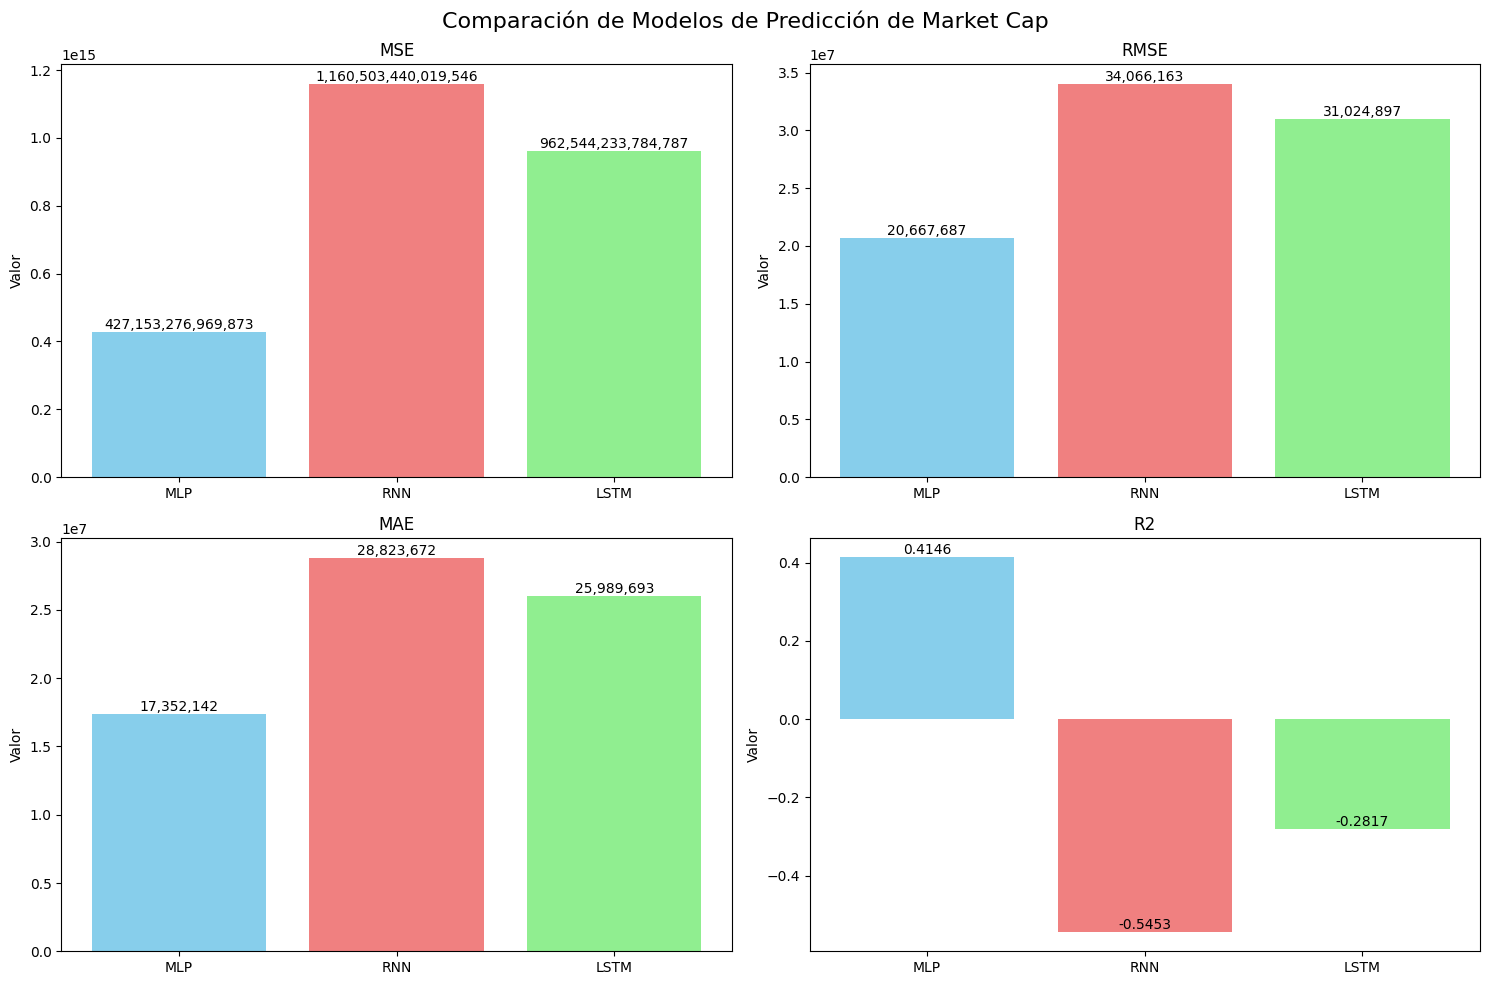

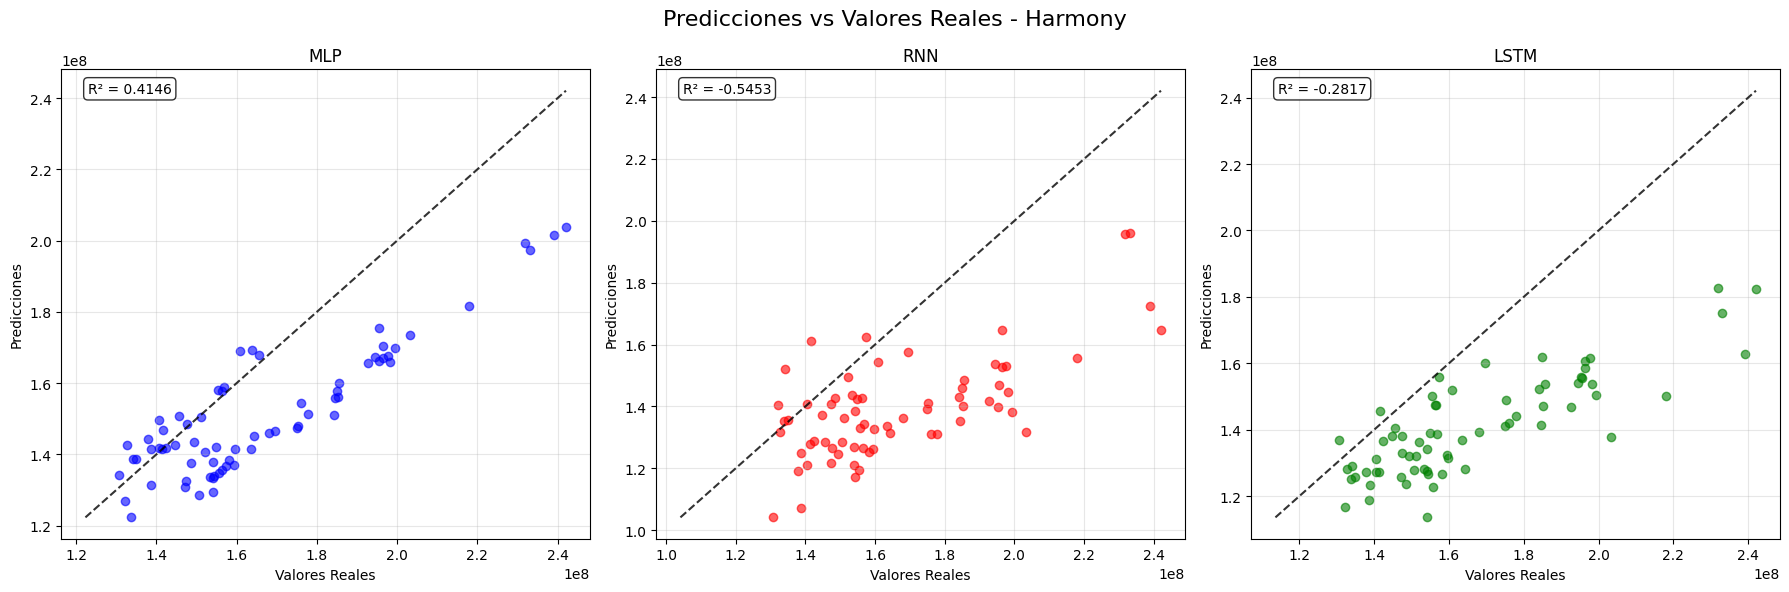

In [30]:
def compare_models(mlp_metrics, rnn_metrics, lstm_metrics):
    """Compara las métricas de los tres modelos"""
    print("🏆 COMPARACIÓN DE MODELOS")
    print("="*60)
    
    # Crear DataFrame con las métricas
    models_comparison = pd.DataFrame({
        'MLP': mlp_metrics,
        'RNN': rnn_metrics if rnn_metrics else {'MSE': None, 'RMSE': None, 'MAE': None, 'R2': None},
        'LSTM': lstm_metrics if lstm_metrics else {'MSE': None, 'RMSE': None, 'MAE': None, 'R2': None}
    }).T
    
    print("Métricas de evaluación:")
    print(models_comparison.round(4))
    
    # Identificar el mejor modelo por cada métrica
    print(f"\n🥇 MEJORES MODELOS POR MÉTRICA:")
    
    for metric in ['MSE', 'RMSE', 'MAE']:
        valid_values = models_comparison[metric].dropna()
        if not valid_values.empty:
            best_model = valid_values.idxmin()
            best_value = valid_values.min()
            print(f"{metric}: {best_model} ({best_value:,.2f})")
    
    # Para R² (mayor es mejor)
    valid_r2 = models_comparison['R2'].dropna()
    if not valid_r2.empty:
        best_r2_model = valid_r2.idxmax()
        best_r2_value = valid_r2.max()
        print(f"R²: {best_r2_model} ({best_r2_value:.4f})")
    
    return models_comparison

def plot_model_comparison(models_comparison):
    """Visualiza la comparación de modelos"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Comparación de Modelos de Predicción de Market Cap', fontsize=16)
    
    metrics = ['MSE', 'RMSE', 'MAE', 'R2']
    colors = ['skyblue', 'lightcoral', 'lightgreen']
    
    for i, metric in enumerate(metrics):
        ax = axes[i//2, i%2]
        valid_data = models_comparison[metric].dropna()
        
        if not valid_data.empty:
            bars = ax.bar(valid_data.index, valid_data.values, color=colors[:len(valid_data)])
            ax.set_title(f'{metric}')
            ax.set_ylabel('Valor')
            
            # Agregar valores en las barras
            for bar, value in zip(bars, valid_data.values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:.4f}' if metric == 'R2' else f'{value:,.0f}',
                       ha='center', va='bottom')
        else:
            ax.text(0.5, 0.5, 'No hay datos', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{metric} - Sin datos')
    
    plt.tight_layout()
    plt.show()

def plot_predictions_vs_actual(test_data_dict, models_dict, token_name='Harmony'):
    """Visualiza predicciones vs valores reales para todos los modelos"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Predicciones vs Valores Reales - {token_name}', fontsize=16)
    
    model_names = ['MLP', 'RNN', 'LSTM']
    colors = ['blue', 'red', 'green']
    
    for i, (model_name, color) in enumerate(zip(model_names, colors)):
        ax = axes[i]
        
        if model_name in test_data_dict and test_data_dict[model_name] is not None:
            X_test, y_test, scaler = test_data_dict[model_name]
            model = models_dict[model_name]
            
            if model_name == 'MLP':
                y_pred = model.predict(X_test)
            else:
                y_pred = model.predict(X_test, verbose=0).flatten()
            
            # Desnormalizar
            y_test_denorm = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
            y_pred_denorm = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
            
            # Scatter plot
            ax.scatter(y_test_denorm, y_pred_denorm, alpha=0.6, color=color)
            
            # Línea de identidad
            min_val = min(y_test_denorm.min(), y_pred_denorm.min())
            max_val = max(y_test_denorm.max(), y_pred_denorm.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8)
            
            ax.set_xlabel('Valores Reales')
            ax.set_ylabel('Predicciones')
            ax.set_title(f'{model_name}')
            ax.grid(True, alpha=0.3)
            
            # R² en el gráfico
            r2 = r2_score(y_test_denorm, y_pred_denorm)
            ax.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax.transAxes, 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.5, 0.5, f'Modelo {model_name}\nno disponible', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{model_name} - No disponible')
    
    plt.tight_layout()
    plt.show()

# Ejecutar comparación y visualizaciones
if 'mlp_metrics' in locals():
    models_comparison = compare_models(
        mlp_metrics, 
        rnn_metrics if 'rnn_metrics' in locals() and rnn_metrics else None,
        lstm_metrics if 'lstm_metrics' in locals() and lstm_metrics else None
    )
    
    # Visualizar comparación
    plot_model_comparison(models_comparison)
    
    # Preparar datos para visualización de predicciones
    test_data_dict = {
        'MLP': mlp_test_data if 'mlp_test_data' in locals() else None,
        'RNN': rnn_test_data if 'rnn_test_data' in locals() and rnn_test_data else None,
        'LSTM': lstm_test_data if 'lstm_test_data' in locals() and lstm_test_data else None
    }
    
    models_dict = {
        'MLP': mlp_model if 'mlp_model' in locals() else None,
        'RNN': rnn_model if 'rnn_model' in locals() else None,
        'LSTM': lstm_model if 'lstm_model' in locals() else None
    }
    
    # Visualizar predicciones vs valores reales
    plot_predictions_vs_actual(test_data_dict, models_dict, 'Harmony')
else:
    print("⚠️ Ejecuta primero los modelos para ver la comparación")

## Entrenamiento MLP sin Último Trimestre

In [35]:
def prepare_data_without_q4(data, token_name, target_column='market_cap'):
    """
    Prepara los datos excluyendo el último trimestre (Q4) del año
    
    Parameters:
    - data: DataFrame con los datos
    - token_name: nombre de la moneda a analizar
    - target_column: columna objetivo a predecir
    
    Returns:
    - Datos preparados sin Q4
    """
    print(f"=== Preparando datos para {token_name} SIN Q4 ===")
    
    # Filtrar datos para la moneda seleccionada
    token_data = data[data['name'] == token_name].copy()
    token_data = token_data.sort_values('date').reset_index(drop=True)
    
    print(f"Registros totales para {token_name}: {len(token_data)}")
    
    # Filtrar para excluir el último trimestre (Q4)
    token_data_no_q4 = token_data[token_data['quarter'] != 4].copy()
    
    print(f"Registros después de excluir Q4: {len(token_data_no_q4)}")
    print(f"Registros eliminados (Q4): {len(token_data) - len(token_data_no_q4)}")
    print(f"Porcentaje de datos mantenidos: {len(token_data_no_q4)/len(token_data)*100:.1f}%")
    
    # Verificar distribución por trimestres
    quarter_counts = token_data_no_q4['quarter'].value_counts().sort_index()
    print(f"\\nDistribución por trimestres (sin Q4):")
    for quarter, count in quarter_counts.items():
        print(f"  Q{quarter}: {count} registros")
    
    # Seleccionar características numéricas
    feature_columns = ['price', 'volume', 'tvl_usd', 'volume_to_marketcap', 
                      'price_change_%', 'market_cap_trend', 'tvl_trend']
    
    # Verificar que las columnas existen
    available_features = [col for col in feature_columns if col in token_data_no_q4.columns]
    print(f"\\nCaracterísticas disponibles: {available_features}")
    
    # Preparar características y objetivo
    X = token_data_no_q4[available_features].values
    y = token_data_no_q4[target_column].values.reshape(-1, 1)
    
    # Escalado de datos
    scaler_features = StandardScaler()
    scaler_target = StandardScaler()
    
    X_scaled = scaler_features.fit_transform(X)
    y_scaled = scaler_target.fit_transform(y)
    
    # División train/test
    test_size = 0.2
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_scaled, test_size=test_size, random_state=42, shuffle=False
    )
    
    print(f"\\nTamaño conjunto entrenamiento: {X_train.shape}")
    print(f"Tamaño conjunto prueba: {X_test.shape}")
    
    return (X_train, X_test, y_train, y_test, 
            scaler_features, scaler_target, available_features, token_data_no_q4)

def train_mlp_without_q4(token_name='Harmony'):
    """Entrena el modelo MLP excluyendo el último trimestre"""
    print(f"🧠 ENTRENANDO MODELO MLP SIN Q4 PARA {token_name.upper()}")
    print("="*70)
    
    # Preparar datos sin Q4
    data_splits = prepare_data_without_q4(eda_data, token_name)
    X_train, X_test, y_train, y_test = data_splits[:4]
    scaler_features, scaler_target, available_features, filtered_data = data_splits[4:]
    
    # Crear y entrenar modelo MLP
    mlp_model_no_q4 = create_mlp_model(X_train.shape[1])
    
    print("\\nEntrenando modelo MLP sin Q4...")
    mlp_model_no_q4.fit(X_train, y_train.ravel())
    
    # Realizar predicciones
    y_train_pred = mlp_model_no_q4.predict(X_train)
    y_test_pred = mlp_model_no_q4.predict(X_test)
    
    # Evaluar modelo
    print("\\n📊 RESULTADOS DEL ENTRENAMIENTO (SIN Q4):")
    train_metrics = evaluate_model(y_train.ravel(), y_train_pred, "MLP Sin Q4 - Entrenamiento", scaler_target)
    
    print("\\n📊 RESULTADOS DE LA PRUEBA (SIN Q4):")
    test_metrics = evaluate_model(y_test.ravel(), y_test_pred, "MLP Sin Q4 - Prueba", scaler_target)
    
    # Información del modelo
    print(f"\\n📈 INFORMACIÓN DEL MODELO:")
    print(f"Número de iteraciones: {mlp_model_no_q4.n_iter_}")
    print(f"Pérdida final: {mlp_model_no_q4.loss_:.6f}")
    print(f"Características utilizadas: {available_features}")
    
    # Información adicional sobre los datos filtrados
    print(f"\\n📅 INFORMACIÓN DE FILTRADO:")
    print(f"Periodo temporal analizado: {filtered_data['date'].min()} a {filtered_data['date'].max()}")
    quarter_distribution = filtered_data['quarter'].value_counts().sort_index()
    for quarter, count in quarter_distribution.items():
        percentage = count / len(filtered_data) * 100
        print(f"Q{quarter}: {count} registros ({percentage:.1f}%)")
    
    return mlp_model_no_q4, test_metrics, (X_test, y_test, scaler_target), filtered_data

# Entrenar el modelo MLP sin Q4
print("🚀 INICIANDO ENTRENAMIENTO MLP SIN ÚLTIMO TRIMESTRE")
print("="*80)

mlp_model_no_q4, mlp_metrics_no_q4, mlp_test_data_no_q4, filtered_data = train_mlp_without_q4('Harmony')

🚀 INICIANDO ENTRENAMIENTO MLP SIN ÚLTIMO TRIMESTRE
🧠 ENTRENANDO MODELO MLP SIN Q4 PARA HARMONY
=== Preparando datos para Harmony SIN Q4 ===
Registros totales para Harmony: 348
Registros después de excluir Q4: 256
Registros eliminados (Q4): 92
Porcentaje de datos mantenidos: 73.6%
\nDistribución por trimestres (sin Q4):
  Q1: 90 registros
  Q2: 74 registros
  Q3: 92 registros
\nCaracterísticas disponibles: ['price', 'volume', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend']
\nTamaño conjunto entrenamiento: (204, 7)
Tamaño conjunto prueba: (52, 7)
\nEntrenando modelo MLP sin Q4...
\n📊 RESULTADOS DEL ENTRENAMIENTO (SIN Q4):

=== Evaluación MLP Sin Q4 - Entrenamiento ===
MSE: 7,070,343,388,267.78
RMSE: 2,659,011.73
MAE: 1,819,751.17
R²: 0.9979
\n📊 RESULTADOS DE LA PRUEBA (SIN Q4):

=== Evaluación MLP Sin Q4 - Prueba ===
MSE: 544,829,907,659,822.12
RMSE: 23,341,591.80
MAE: 21,569,278.29
R²: 0.2455
\n📈 INFORMACIÓN DEL MODELO:
Número de iteraciones: 107
Pér

\n🔄 COMPARACIÓN MLP ORIGINAL vs MLP SIN Q4
Métricas de evaluación:
                       MSE          RMSE           MAE      R2
MLP Original  4.271533e+14  2.066769e+07  1.735214e+07  0.4146
MLP Sin Q4    5.448299e+14  2.334159e+07  2.156928e+07  0.2455
\n📊 ANÁLISIS DE DIFERENCIAS:
MSE: 427,153,276,969,873.31 → 544,829,907,659,822.12 (+117,676,630,689,948.81, +27.5%) - EMPEORA
RMSE: 20,667,686.78 → 23,341,591.80 (+2,673,905.01, +12.9%) - EMPEORA
MAE: 17,352,142.03 → 21,569,278.29 (+4,217,136.27, +24.3%) - EMPEORA
R2: 0.4146 → 0.2455 (-0.1691) - EMPEORA


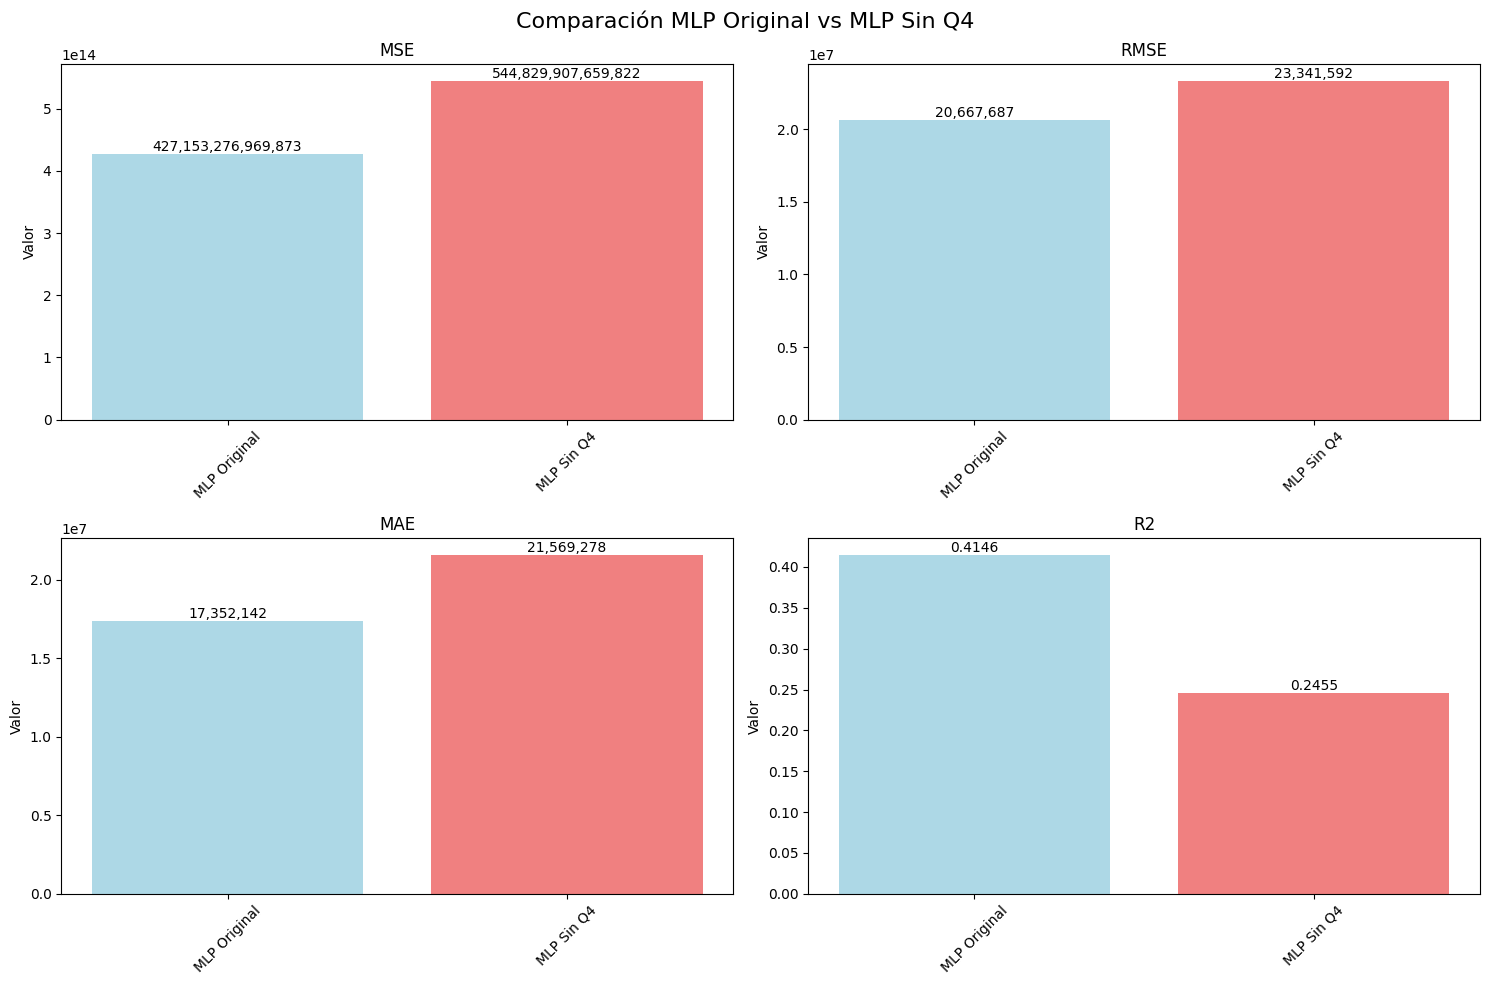

In [36]:
# Comparar MLP original vs MLP sin Q4
def compare_mlp_models(mlp_original_metrics, mlp_no_q4_metrics):
    """Compara el MLP original con el MLP sin Q4"""
    print("\\n" + "🔄 COMPARACIÓN MLP ORIGINAL vs MLP SIN Q4")
    print("="*70)
    
    # Crear DataFrame comparativo
    comparison_df = pd.DataFrame({
        'MLP Original': mlp_original_metrics,
        'MLP Sin Q4': mlp_no_q4_metrics
    }).T
    
    print("Métricas de evaluación:")
    print(comparison_df.round(4))
    
    # Calcular diferencias
    print("\\n📊 ANÁLISIS DE DIFERENCIAS:")
    for metric in ['MSE', 'RMSE', 'MAE', 'R2']:
        original_val = mlp_original_metrics[metric]
        no_q4_val = mlp_no_q4_metrics[metric]
        
        if metric == 'R2':
            # Para R², mayor es mejor
            diff = no_q4_val - original_val
            improvement = "MEJORA" if diff > 0 else "EMPEORA"
            print(f"{metric}: {original_val:.4f} → {no_q4_val:.4f} ({diff:+.4f}) - {improvement}")
        else:
            # Para MSE, RMSE, MAE, menor es mejor
            diff = no_q4_val - original_val
            improvement = "MEJORA" if diff < 0 else "EMPEORA"
            percent_change = (diff / original_val) * 100
            print(f"{metric}: {original_val:,.2f} → {no_q4_val:,.2f} ({diff:+,.2f}, {percent_change:+.1f}%) - {improvement}")
    
    return comparison_df

def plot_mlp_comparison(mlp_original_metrics, mlp_no_q4_metrics):
    """Visualiza la comparación entre los dos modelos MLP"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Comparación MLP Original vs MLP Sin Q4', fontsize=16)
    
    metrics = ['MSE', 'RMSE', 'MAE', 'R2']
    colors = ['lightblue', 'lightcoral']
    
    for i, metric in enumerate(metrics):
        ax = axes[i//2, i%2]
        
        models = ['MLP Original', 'MLP Sin Q4']
        values = [mlp_original_metrics[metric], mlp_no_q4_metrics[metric]]
        
        bars = ax.bar(models, values, color=colors)
        ax.set_title(f'{metric}')
        ax.set_ylabel('Valor')
        
        # Agregar valores en las barras
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.4f}' if metric == 'R2' else f'{value:,.0f}',
                   ha='center', va='bottom')
        
        # Rotar etiquetas del eje x
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Ejecutar comparación si ambos modelos están disponibles
if 'mlp_metrics' in locals() and 'mlp_metrics_no_q4' in locals():
    mlp_comparison = compare_mlp_models(mlp_metrics, mlp_metrics_no_q4)
    plot_mlp_comparison(mlp_metrics, mlp_metrics_no_q4)
else:
    print("⚠️ Asegúrate de haber ejecutado ambos entrenamientos de MLP para ver la comparación")

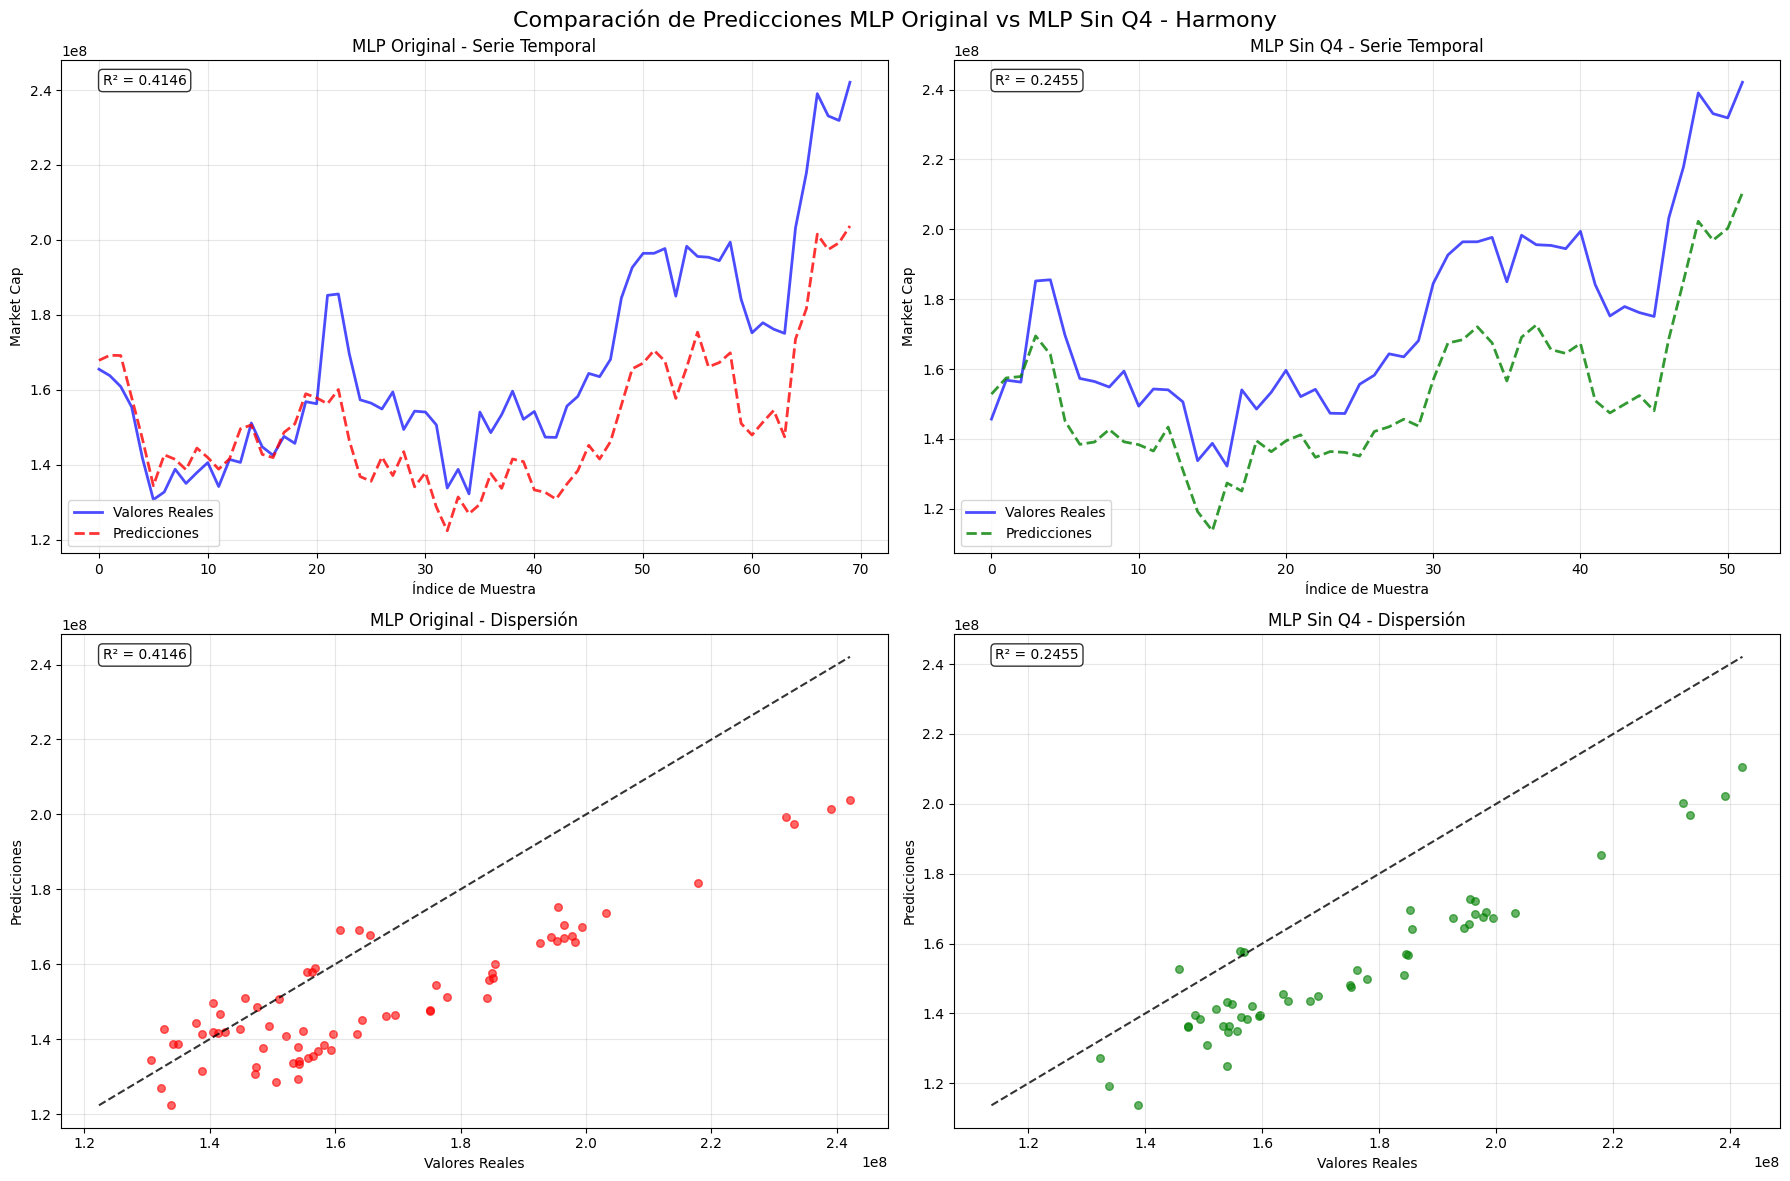

📊 ESTADÍSTICAS COMPARATIVAS
MLP Original:
  R²: 0.4146
  RMSE: 20,667,686.78
  MAE: 17,352,142.03
  Muestras de prueba: 70

MLP Sin Q4:
  R²: 0.2455
  RMSE: 23,341,591.80
  MAE: 21,569,278.29
  Muestras de prueba: 52


In [38]:
def plot_mlp_predictions_comparison(mlp_original_data, mlp_no_q4_data, token_name='Harmony'):
    """
    Crea gráficos de líneas comparando predicciones vs valores reales para ambos modelos MLP
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'Comparación de Predicciones MLP Original vs MLP Sin Q4 - {token_name}', fontsize=16)
    
    # Preparar datos del MLP original
    X_test_orig, y_test_orig, scaler_orig = mlp_original_data
    y_pred_orig = mlp_model.predict(X_test_orig)
    
    # Desnormalizar datos originales
    y_test_orig_denorm = scaler_orig.inverse_transform(y_test_orig.reshape(-1, 1)).flatten()
    y_pred_orig_denorm = scaler_orig.inverse_transform(y_pred_orig.reshape(-1, 1)).flatten()
    
    # Preparar datos del MLP sin Q4
    X_test_no_q4, y_test_no_q4, scaler_no_q4 = mlp_no_q4_data
    y_pred_no_q4 = mlp_model_no_q4.predict(X_test_no_q4)
    
    # Desnormalizar datos sin Q4
    y_test_no_q4_denorm = scaler_no_q4.inverse_transform(y_test_no_q4.reshape(-1, 1)).flatten()
    y_pred_no_q4_denorm = scaler_no_q4.inverse_transform(y_pred_no_q4.reshape(-1, 1)).flatten()
    
    # Gráfico 1: Series temporales MLP Original
    ax1 = axes[0, 0]
    indices_orig = range(len(y_test_orig_denorm))
    ax1.plot(indices_orig, y_test_orig_denorm, 'b-', label='Valores Reales', linewidth=2, alpha=0.7)
    ax1.plot(indices_orig, y_pred_orig_denorm, 'r--', label='Predicciones', linewidth=2, alpha=0.8)
    ax1.set_title('MLP Original - Serie Temporal')
    ax1.set_xlabel('Índice de Muestra')
    ax1.set_ylabel('Market Cap')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Añadir R² en el gráfico
    r2_orig = r2_score(y_test_orig_denorm, y_pred_orig_denorm)
    ax1.text(0.05, 0.95, f'R² = {r2_orig:.4f}', transform=ax1.transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Gráfico 2: Series temporales MLP Sin Q4
    ax2 = axes[0, 1]
    indices_no_q4 = range(len(y_test_no_q4_denorm))
    ax2.plot(indices_no_q4, y_test_no_q4_denorm, 'b-', label='Valores Reales', linewidth=2, alpha=0.7)
    ax2.plot(indices_no_q4, y_pred_no_q4_denorm, 'g--', label='Predicciones', linewidth=2, alpha=0.8)
    ax2.set_title('MLP Sin Q4 - Serie Temporal')
    ax2.set_xlabel('Índice de Muestra')
    ax2.set_ylabel('Market Cap')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Añadir R² en el gráfico
    r2_no_q4 = r2_score(y_test_no_q4_denorm, y_pred_no_q4_denorm)
    ax2.text(0.05, 0.95, f'R² = {r2_no_q4:.4f}', transform=ax2.transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Gráfico 3: Scatter plot MLP Original
    ax3 = axes[1, 0]
    ax3.scatter(y_test_orig_denorm, y_pred_orig_denorm, alpha=0.6, color='red', s=30)
    
    # Línea de identidad
    min_val_orig = min(y_test_orig_denorm.min(), y_pred_orig_denorm.min())
    max_val_orig = max(y_test_orig_denorm.max(), y_pred_orig_denorm.max())
    ax3.plot([min_val_orig, max_val_orig], [min_val_orig, max_val_orig], 'k--', alpha=0.8)
    
    ax3.set_xlabel('Valores Reales')
    ax3.set_ylabel('Predicciones')
    ax3.set_title('MLP Original - Dispersión')
    ax3.grid(True, alpha=0.3)
    ax3.text(0.05, 0.95, f'R² = {r2_orig:.4f}', transform=ax3.transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Gráfico 4: Scatter plot MLP Sin Q4
    ax4 = axes[1, 1]
    ax4.scatter(y_test_no_q4_denorm, y_pred_no_q4_denorm, alpha=0.6, color='green', s=30)
    
    # Línea de identidad
    min_val_no_q4 = min(y_test_no_q4_denorm.min(), y_pred_no_q4_denorm.min())
    max_val_no_q4 = max(y_test_no_q4_denorm.max(), y_pred_no_q4_denorm.max())
    ax4.plot([min_val_no_q4, max_val_no_q4], [min_val_no_q4, max_val_no_q4], 'k--', alpha=0.8)
    
    ax4.set_xlabel('Valores Reales')
    ax4.set_ylabel('Predicciones')
    ax4.set_title('MLP Sin Q4 - Dispersión')
    ax4.grid(True, alpha=0.3)
    ax4.text(0.05, 0.95, f'R² = {r2_no_q4:.4f}', transform=ax4.transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar estadísticas comparativas
    print("📊 ESTADÍSTICAS COMPARATIVAS")
    print("="*50)
    print(f"MLP Original:")
    print(f"  R²: {r2_orig:.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_orig_denorm, y_pred_orig_denorm)):,.2f}")
    print(f"  MAE: {mean_absolute_error(y_test_orig_denorm, y_pred_orig_denorm):,.2f}")
    print(f"  Muestras de prueba: {len(y_test_orig_denorm)}")
    
    print(f"\nMLP Sin Q4:")
    print(f"  R²: {r2_no_q4:.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_no_q4_denorm, y_pred_no_q4_denorm)):,.2f}")
    print(f"  MAE: {mean_absolute_error(y_test_no_q4_denorm, y_pred_no_q4_denorm):,.2f}")
    print(f"  Muestras de prueba: {len(y_test_no_q4_denorm)}")

# Ejecutar la comparación visual
if 'mlp_test_data' in locals() and 'mlp_test_data_no_q4' in locals():
    plot_mlp_predictions_comparison(mlp_test_data, mlp_test_data_no_q4, 'Harmony')
else:
    print("⚠️ Asegúrate de haber ejecutado ambos entrenamientos de MLP para ver la comparación")

📊 ANÁLISIS DEL IMPACTO DE ELIMINAR Q4
\n📈 ESTADÍSTICAS GENERALES:
Registros totales: 348
Registros sin Q4: 256
Registros solo Q4: 92
Porcentaje de Q4: 26.4%
\n💰 ANÁLISIS DE MARKET_CAP:
Media completa: 204,102,123.31
Media sin Q4: 187,487,661.39
Media solo Q4: 250,333,669.52
\nDesviación estándar completa: 79,184,025.95
Desviación estándar sin Q4: 53,925,785.56
Desviación estándar solo Q4: 113,238,421.59
\n📊 COMPARACIÓN POR CARACTERÍSTICAS:
\nprice:
  Completo: 0.0163
  Sin Q4: 0.0148
  Solo Q4: 0.0203
  Diferencia (Q4 vs Sin Q4): 0.0055
\nvolume:
  Completo: 19273815.3728
  Sin Q4: 11725416.1136
  Solo Q4: 40278056.7898
  Diferencia (Q4 vs Sin Q4): 28552640.6762
\ntvl_usd:
  Completo: 2166358.0259
  Sin Q4: 1943298.7070
  Solo Q4: 2787044.8261
  Diferencia (Q4 vs Sin Q4): 843746.1191
\nprice_change_%:
  Completo: 0.0990
  Sin Q4: -0.2105
  Solo Q4: 0.9603
  Diferencia (Q4 vs Sin Q4): 1.1709


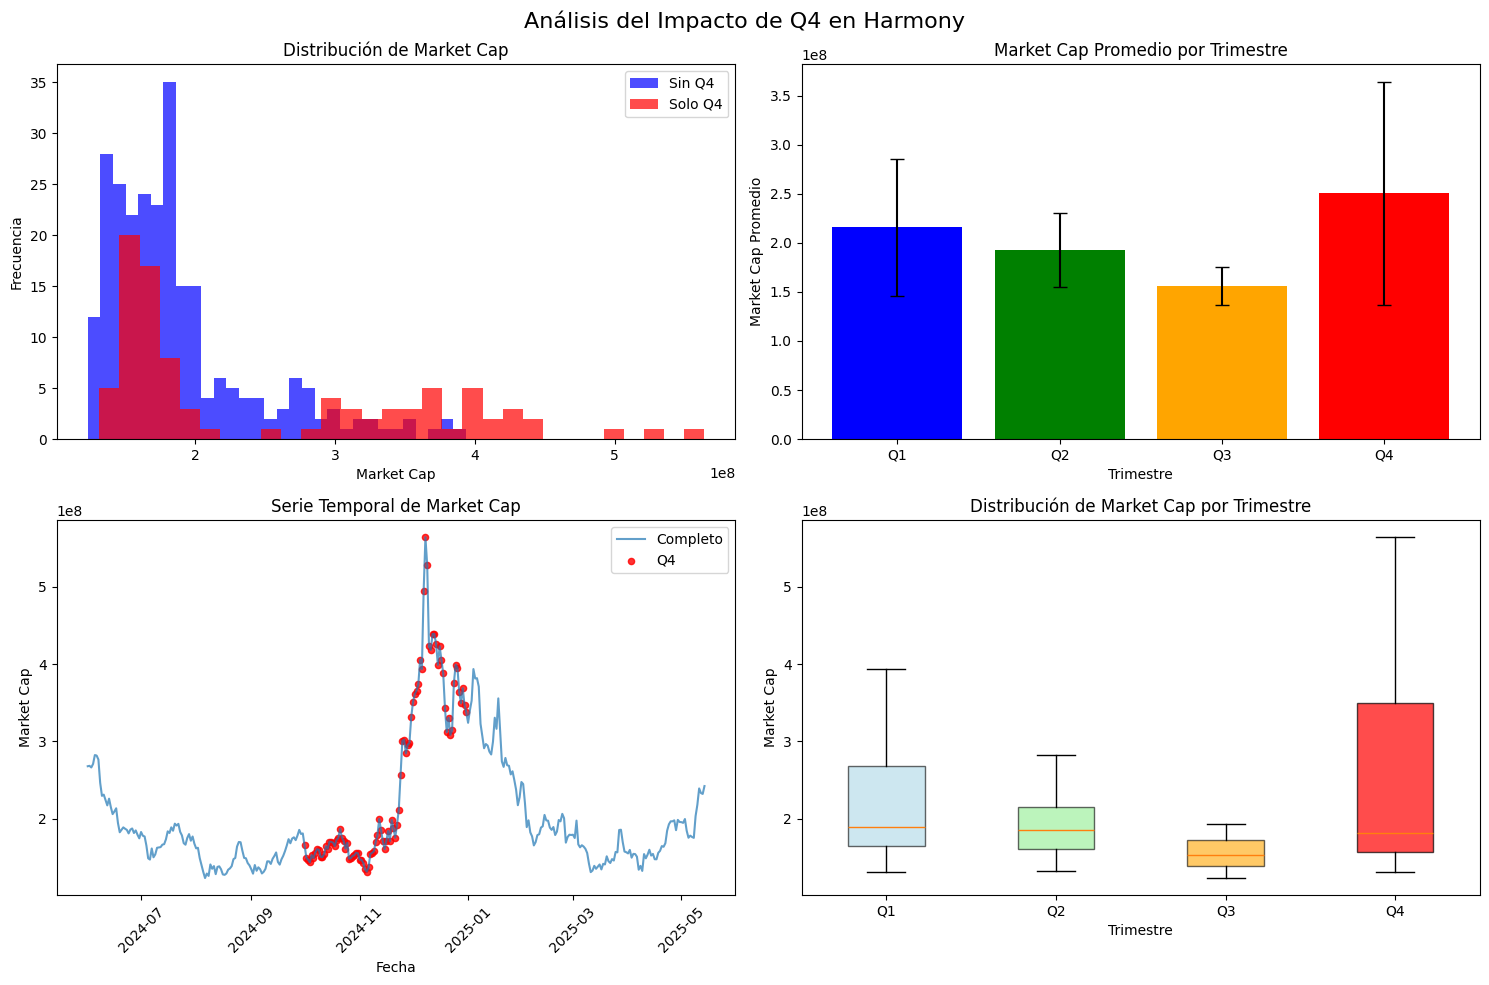

In [42]:
# Análisis del impacto de eliminar Q4
def analyze_q4_impact(token_name='Harmony'):
    """Analiza el impacto de eliminar Q4 en los datos"""
    print("📊 ANÁLISIS DEL IMPACTO DE ELIMINAR Q4")
    print("="*50)
    
    # Obtener datos completos
    token_data_full = eda_data[eda_data['name'] == token_name].copy()
    token_data_no_q4 = token_data_full[token_data_full['quarter'] != 4].copy()
    token_data_q4_only = token_data_full[token_data_full['quarter'] == 4].copy()
    
    print(f"\\n📈 ESTADÍSTICAS GENERALES:")
    print(f"Registros totales: {len(token_data_full)}")
    print(f"Registros sin Q4: {len(token_data_no_q4)}")
    print(f"Registros solo Q4: {len(token_data_q4_only)}")
    print(f"Porcentaje de Q4: {len(token_data_q4_only)/len(token_data_full)*100:.1f}%")
    
    # Análisis de market_cap
    target_col = 'market_cap'
    
    print(f"\\n💰 ANÁLISIS DE {target_col.upper()}:")
    print(f"Media completa: {token_data_full[target_col].mean():,.2f}")
    print(f"Media sin Q4: {token_data_no_q4[target_col].mean():,.2f}")
    print(f"Media solo Q4: {token_data_q4_only[target_col].mean():,.2f}")
    
    print(f"\\nDesviación estándar completa: {token_data_full[target_col].std():,.2f}")
    print(f"Desviación estándar sin Q4: {token_data_no_q4[target_col].std():,.2f}")
    print(f"Desviación estándar solo Q4: {token_data_q4_only[target_col].std():,.2f}")
    
    # Análisis por características principales
    features = ['price', 'volume', 'tvl_usd', 'price_change_%']
    
    print(f"\\n📊 COMPARACIÓN POR CARACTERÍSTICAS:")
    for feature in features:
        if feature in token_data_full.columns:
            full_mean = token_data_full[feature].mean()
            no_q4_mean = token_data_no_q4[feature].mean()
            q4_mean = token_data_q4_only[feature].mean()
            
            print(f"\\n{feature}:")
            print(f"  Completo: {full_mean:.4f}")
            print(f"  Sin Q4: {no_q4_mean:.4f}")
            print(f"  Solo Q4: {q4_mean:.4f}")
            print(f"  Diferencia (Q4 vs Sin Q4): {q4_mean - no_q4_mean:.4f}")
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Análisis del Impacto de Q4 en {token_name}', fontsize=16)
    
    # Gráfico 1: Distribución de market_cap
    ax1 = axes[0, 0]
    ax1.hist(token_data_no_q4[target_col], bins=30, alpha=0.7, label='Sin Q4', color='blue')
    ax1.hist(token_data_q4_only[target_col], bins=30, alpha=0.7, label='Solo Q4', color='red')
    ax1.set_title('Distribución de Market Cap')
    ax1.set_xlabel('Market Cap')
    ax1.set_ylabel('Frecuencia')
    ax1.legend()
    
    # Gráfico 2: Market cap por trimestre
    ax2 = axes[0, 1]
    quarterly_stats = token_data_full.groupby('quarter')[target_col].agg(['mean', 'std']).reset_index()
    ax2.bar(quarterly_stats['quarter'], quarterly_stats['mean'], 
            yerr=quarterly_stats['std'], capsize=5, color=['blue', 'green', 'orange', 'red'])
    ax2.set_title('Market Cap Promedio por Trimestre')
    ax2.set_xlabel('Trimestre')
    ax2.set_ylabel('Market Cap Promedio')
    ax2.set_xticks([1, 2, 3, 4])
    ax2.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    
    # Gráfico 3: Serie temporal
    ax3 = axes[1, 0]
    ax3.plot(token_data_full['date'], token_data_full[target_col], alpha=0.7, label='Completo')
    ax3.scatter(token_data_q4_only['date'], token_data_q4_only[target_col], 
               color='red', alpha=0.8, s=20, label='Q4')
    ax3.set_title('Serie Temporal de Market Cap')
    ax3.set_xlabel('Fecha')
    ax3.set_ylabel('Market Cap')
    ax3.legend()
    ax3.tick_params(axis='x', rotation=45)
    
    # Gráfico 4: Box plot por trimestre
    ax4 = axes[1, 1]
    quarterly_data = [token_data_full[token_data_full['quarter'] == q][target_col].values 
                     for q in [1, 2, 3, 4]]
    
    # Crear boxplot con colores personalizados
    colors = ['lightblue', 'lightgreen', 'orange', 'red']
    box_plot = ax4.boxplot(quarterly_data, labels=['Q1', 'Q2', 'Q3', 'Q4'], patch_artist=True)
    
    # Colorear las cajas
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        if color == 'red':  # Q4 en rojo con transparencia
            patch.set_alpha(0.7)
        else:
            patch.set_alpha(0.6)
    
    ax4.set_title('Distribución de Market Cap por Trimestre')
    ax4.set_xlabel('Trimestre')
    ax4.set_ylabel('Market Cap')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'full_data_stats': token_data_full[target_col].describe(),
        'no_q4_stats': token_data_no_q4[target_col].describe(),
        'q4_only_stats': token_data_q4_only[target_col].describe()
    }

# Ejecutar análisis de impacto
impact_analysis = analyze_q4_impact('Harmony')